# Vessel Analysis

## 1. Import packages

In [1]:
import pandas as pd
import numpy as np

import anndata as ad
import scanpy as sc
# import scimap as sm

import seaborn as sns
import matplotlib.pyplot as plt
# from matplotlib.pyplot import rc_context

import warnings
warnings.filterwarnings('ignore')

## 2. Lymph Node create anndata object

In [45]:
annotDF = pd.read_csv('C:/Users/smith6jt/Spleen/Vessel_marker_intensities_LN_all_with_regions.csv')
annotDF.reset_index(drop=True,inplace=True)
list(annotDF.columns.tolist())

['Image',
 'Object ID',
 'Object type',
 'Name',
 'Classification',
 'Parent',
 'ROI',
 'Centroid X µm',
 'Centroid Y µm',
 'Area µm^2',
 'Perimeter µm',
 'Length µm',
 'Circularity',
 'Solidity',
 'Max diameter µm',
 'Min diameter µm',
 'ROI: 0.38 µm per pixel: CD1c: Mean',
 'ROI: 0.38 µm per pixel: CD3e: Mean',
 'ROI: 0.38 µm per pixel: CD4: Mean',
 'ROI: 0.38 µm per pixel: CD5: Mean',
 'ROI: 0.38 µm per pixel: CD8: Mean',
 'ROI: 0.38 µm per pixel: CD11c: Mean',
 'ROI: 0.38 µm per pixel: CD15: Mean',
 'ROI: 0.38 µm per pixel: CD20: Mean',
 'ROI: 0.38 µm per pixel: CD21: Mean',
 'ROI: 0.38 µm per pixel: CD31: Mean',
 'ROI: 0.38 µm per pixel: CD34: Mean',
 'ROI: 0.38 µm per pixel: CD35: Mean',
 'ROI: 0.38 µm per pixel: CD44: Mean',
 'ROI: 0.38 µm per pixel: CD45: Mean',
 'ROI: 0.38 µm per pixel: CD45RO: Mean',
 'ROI: 0.38 µm per pixel: CD68: Mean',
 'ROI: 0.38 µm per pixel: CD107a: Mean',
 'ROI: 0.38 µm per pixel: CD163: Mean',
 'ROI: 0.38 µm per pixel: CollagenIV: Mean',
 'ROI: 0.38 µ

In [46]:
annotDF.isna().sum()

Image                                           0
Object ID                                       0
Object type                                     0
Name                                        13885
Classification                                  0
Parent                                          0
ROI                                             0
Centroid X µm                                   0
Centroid Y µm                                   0
Area µm^2                                       0
Perimeter µm                                    0
Length µm                                     415
Circularity                                   423
Solidity                                      415
Max diameter µm                               415
Min diameter µm                               415
ROI: 0.38 µm per pixel: CD1c: Mean           2040
ROI: 0.38 µm per pixel: CD3e: Mean            417
ROI: 0.38 µm per pixel: CD4: Mean            2754
ROI: 0.38 µm per pixel: CD5: Mean            4559


In [47]:
annotDF.fillna(1, inplace=True)
annotDF.isna().sum()

Image                                       0
Object ID                                   0
Object type                                 0
Name                                        0
Classification                              0
Parent                                      0
ROI                                         0
Centroid X µm                               0
Centroid Y µm                               0
Area µm^2                                   0
Perimeter µm                                0
Length µm                                   0
Circularity                                 0
Solidity                                    0
Max diameter µm                             0
Min diameter µm                             0
ROI: 0.38 µm per pixel: CD1c: Mean          0
ROI: 0.38 µm per pixel: CD3e: Mean          0
ROI: 0.38 µm per pixel: CD4: Mean           0
ROI: 0.38 µm per pixel: CD5: Mean           0
ROI: 0.38 µm per pixel: CD8: Mean           0
ROI: 0.38 µm per pixel: CD11c: Mea

In [49]:
spatialCols = ['Image',
 'Parent',
 'Centroid X µm',
 'Centroid Y µm',
 'Area µm^2', 
 'Perimeter µm', 
 'Length µm', 
 'Circularity', 
 'Solidity',
'Max diameter µm', 
'Min diameter µm'
]

spatialNames = {'Image':'imageid',
 'Parent':'Parent',
 'Centroid X µm':'X_centroid',  
 'Centroid Y µm':'Y_centroid',
 'Area µm^2':'Area', 
 'Perimeter µm':'Perimeter', 
 'Length µm':'Length', 
 'Circularity': 'Circularity', 
 'Solidity':'Solidity',
'Max diameter µm':'Max diameter', 
'Min diameter µm':'Min diameter'
}                

spatDF = annotDF[spatialCols] 
spatDF.rename(columns=spatialNames, inplace=True)

# Create the filter mask
filter_mask = spatDF['imageid'] != 1

# Apply the same filter to both DataFrames
spatDF = spatDF[filter_mask]
annotDF = annotDF[filter_mask]

# Reset indices to ensure they align
spatDF.reset_index(drop=True, inplace=True)
annotDF.reset_index(drop=True, inplace=True)

spatDF

,imageid,Parent,X_centroid,Y_centroid,Area,Perimeter,Length,Circularity,Solidity,Max diameter,Min diameter
0,20_6_N3_R3_Manual_Annotation,Root object (Image),1936.50,1834.90,6063980.00,104332.00,1.0000,1.0000,1.0000,1.0000,1.0000
1,20_6_N3_R3_Manual_Annotation,Annotation (Paracortex),1751.70,279.51,9529.30,1202.60,1202.6319,0.0828,0.2765,441.1972,96.4785
2,20_6_N3_R3_Manual_Annotation,Annotation (Paracortex),3386.90,839.61,4228.60,533.59,533.5943,0.1866,0.5914,202.9198,47.5408
3,20_6_N3_R3_Manual_Annotation,Annotation (Paracortex),2036.40,1755.50,3851.30,575.39,575.3854,0.1462,0.6018,216.6477,36.3496
4,20_6_N3_R3_Manual_Annotation,Annotation (Paracortex),470.65,2298.30,3589.70,485.55,485.5543,0.1913,0.7777,171.4742,30.2890
...,...,...,...,...,...,...,...,...,...,...,...
13880,20_08_N7_R3_Manual_Annotation_v2,Root object (Image),261.19,828.07,21.93,21.13,21.1345,0.6171,0.9362,5.7877,5.2836
13881,20_08_N7_R3_Manual_Annotation_v2,Root object (Image),2894.00,2386.50,21.08,24.15,24.1523,0.4541,0.8916,6.3084,5.2834
13882,20_08_N7_R3_Manual_Annotation_v2,Root object (Image),1349.00,2041.20,21.08,21.89,21.8894,0.5529,0.9024,6.5911,4.5288
13883,20_08_N7_R3_Manual_Annotation_v2,Root object (Image),3297.00,2404.90,20.79,21.89,21.8887,0.5454,0.8985,5.9788,4.9636


In [53]:
# Create a boolean mask for rows to keep
keep_mask = (spatDF['Parent'] != 'Annotation (HighEndothelialVennule)') & (spatDF['Parent'] != 'Annotation (Vessel)')

# Filter both dataframes using the mask
spatDF = spatDF[keep_mask]
annotDF = annotDF[keep_mask]
annotDF = annotDF.drop([ 
 'Area µm^2', 
 'Perimeter µm', 
 'Length µm', 
 'Circularity', 
 'Solidity',
'Max diameter µm', 
'Min diameter µm'
], axis=1)

In [54]:
list(annotDF.columns.tolist())

['ROI: 0.38 µm per pixel: CD1c: Mean',
 'ROI: 0.38 µm per pixel: CD3e: Mean',
 'ROI: 0.38 µm per pixel: CD4: Mean',
 'ROI: 0.38 µm per pixel: CD5: Mean',
 'ROI: 0.38 µm per pixel: CD8: Mean',
 'ROI: 0.38 µm per pixel: CD11c: Mean',
 'ROI: 0.38 µm per pixel: CD15: Mean',
 'ROI: 0.38 µm per pixel: CD20: Mean',
 'ROI: 0.38 µm per pixel: CD21: Mean',
 'ROI: 0.38 µm per pixel: CD31: Mean',
 'ROI: 0.38 µm per pixel: CD34: Mean',
 'ROI: 0.38 µm per pixel: CD35: Mean',
 'ROI: 0.38 µm per pixel: CD44: Mean',
 'ROI: 0.38 µm per pixel: CD45: Mean',
 'ROI: 0.38 µm per pixel: CD45RO: Mean',
 'ROI: 0.38 µm per pixel: CD68: Mean',
 'ROI: 0.38 µm per pixel: CD107a: Mean',
 'ROI: 0.38 µm per pixel: CD163: Mean',
 'ROI: 0.38 µm per pixel: CollagenIV: Mean',
 'ROI: 0.38 µm per pixel: DAPI: Mean',
 'ROI: 0.38 µm per pixel: FoxP3: Mean',
 'ROI: 0.38 µm per pixel: HLADR: Mean',
 'ROI: 0.38 µm per pixel: Ki67: Mean',
 'ROI: 0.38 µm per pixel: Lyve1: Mean',
 'ROI: 0.38 µm per pixel: Podoplanin: Mean',
 'ROI: 

In [36]:
annotDF.rename(columns={
 'Area µm^2':'Area',
 'Length µm':'Length',
 'Max diameter µm':'Max_Diameter',
 'Min diameter µm':'Min_Diameter',
  'Circularity':'Circularity',
 'Perimeter µm':'Perimeter'}, inplace=True)

In [55]:
newNames = {col:col.split(' ')[5] for col in annotDF.columns[0::] if 'ROI' in col}
annotDF.rename(newNames, inplace=True, axis=1)
annotDF.head()

,CD1c:,CD3e:,CD4:,CD5:,CD8:,CD11c:,CD15:,CD20:,CD21:,CD31:,...,CollagenIV:,DAPI:,FoxP3:,HLADR:,Ki67:,Lyve1:,Podoplanin:,SMActin:,Vimentin:,ECAD:
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,...,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0
1,471.4675,2628.2575,4170.2096,1832.7192,446.8353,408.6588,449.5317,440.8505,1273.5312,7050.4507,...,1931.2417,8455.5367,2254.8883,982.0442,47.9553,4519.5065,3429.9955,10723.9636,7131.4175,1.0
2,641.4271,2264.0786,2458.7468,934.0252,331.5577,315.2226,633.1672,1257.1561,959.9475,9364.2157,...,609.7343,11625.9232,1519.3240,608.6796,169.5372,3701.1663,1646.5788,5341.9604,9333.9838,1.0
3,609.4252,2082.5187,2613.4575,995.3358,239.7179,376.3254,1206.1023,205.9047,509.6681,6372.0589,...,1321.6189,8232.8992,749.1555,558.3704,75.8290,3527.5972,2396.8963,7874.9644,4480.3501,1.0
4,686.3919,3831.3926,5823.6496,3119.9454,557.8792,221.8401,765.2211,817.4903,1982.3853,6469.9639,...,2497.4647,8040.0512,3859.2003,1379.9333,547.7691,3690.2092,3828.8243,4860.3103,9759.9452,1.0


In [56]:
newNames = {col:col.split(':')[0] for col in annotDF.columns[0::] if ':' in col}
annotDF.rename(newNames, inplace=True, axis=1)
annotDF.head()

,CD1c,CD3e,CD4,CD5,CD8,CD11c,CD15,CD20,CD21,CD31,...,CollagenIV,DAPI,FoxP3,HLADR,Ki67,Lyve1,Podoplanin,SMActin,Vimentin,ECAD
0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,...,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0
1,471.4675,2628.2575,4170.2096,1832.7192,446.8353,408.6588,449.5317,440.8505,1273.5312,7050.4507,...,1931.2417,8455.5367,2254.8883,982.0442,47.9553,4519.5065,3429.9955,10723.9636,7131.4175,1.0
2,641.4271,2264.0786,2458.7468,934.0252,331.5577,315.2226,633.1672,1257.1561,959.9475,9364.2157,...,609.7343,11625.9232,1519.3240,608.6796,169.5372,3701.1663,1646.5788,5341.9604,9333.9838,1.0
3,609.4252,2082.5187,2613.4575,995.3358,239.7179,376.3254,1206.1023,205.9047,509.6681,6372.0589,...,1321.6189,8232.8992,749.1555,558.3704,75.8290,3527.5972,2396.8963,7874.9644,4480.3501,1.0
4,686.3919,3831.3926,5823.6496,3119.9454,557.8792,221.8401,765.2211,817.4903,1982.3853,6469.9639,...,2497.4647,8040.0512,3859.2003,1379.9333,547.7691,3690.2092,3828.8243,4860.3103,9759.9452,1.0


In [57]:
from sklearn.preprocessing import MinMaxScaler

# Identify marker columns to be normalized (assuming they are not the morphological features)
morph_features = ['Area', 'Length', 'Circularity', 'Max_Diameter', 'Solidity', 'Min_Diameter','Perimeter']
marker_columns = [col for col in annotDF.columns if col not in morph_features]

# Create a scaler object
scaler = MinMaxScaler()

# Fit and transform the marker columns
annotDF[marker_columns] = scaler.fit_transform(annotDF[marker_columns])

annotDF.head()

,CD1c,CD3e,CD4,CD5,CD8,CD11c,CD15,CD20,CD21,CD31,...,CollagenIV,DAPI,FoxP3,HLADR,Ki67,Lyve1,Podoplanin,SMActin,Vimentin,ECAD
0,0.000042,0.000041,0.000037,0.000035,0.000033,0.000019,0.000017,0.000019,0.000020,0.000000,...,0.000036,0.000000,0.000053,0.000028,0.000032,0.000018,0.000016,0.000015,0.000021,0.000144
1,0.019849,0.107002,0.155222,0.063624,0.014811,0.007945,0.007513,0.008521,0.024992,0.129873,...,0.069287,0.130041,0.119428,0.027745,0.001548,0.082935,0.055909,0.165237,0.150297,0.000144
2,0.027005,0.092176,0.091518,0.032425,0.010990,0.006129,0.010582,0.024299,0.018838,0.172500,...,0.021875,0.178805,0.080470,0.017197,0.005473,0.067918,0.026839,0.082310,0.196717,0.000144
3,0.025657,0.084784,0.097277,0.034554,0.007946,0.007317,0.020158,0.003980,0.010002,0.117375,...,0.047415,0.126616,0.039678,0.015775,0.002448,0.064733,0.039069,0.121339,0.094425,0.000144
4,0.028898,0.155984,0.216765,0.108311,0.018492,0.004313,0.012789,0.015801,0.038902,0.119179,...,0.089601,0.123650,0.204399,0.038987,0.017684,0.067717,0.062410,0.074889,0.205695,0.000144


In [58]:
vdata = ad.AnnData (annotDF)
vdata.obs = spatDF

print("Before standardization:")
print(vdata.obs.Parent.value_counts())

Before standardization:
Parent
Annotation (Paracortex)    10282
Root object (Image)         1243
Annotation (Follicle)       1131
Annotation (Sinus)           598
Annotation (Capsule)         567
Name: count, dtype: int64


In [59]:
vdata = ad.AnnData (annotDF)
vdata.obs = spatDF

print("Before standardization:")
print(vdata.obs.Parent.value_counts())

replacement_map = {
    'Annotation (Paracortex)': 'Paracortex',
    'Annotation (Follicle)': 'Follicle',
    'Annotation (Sinus)': 'Sinus',
    'Annotation (Capsule)': 'Capsule',
    'Root object (Image)': 'Border'
}

vdata.obs['Parent'] = vdata.obs['Parent'].replace(replacement_map)

print("\nAfter standardization:")
print(vdata.obs.Parent.value_counts())

print("\nUnique values after standardization:")
print(vdata.obs.Parent.unique())

Before standardization:
Parent
Annotation (Paracortex)    10282
Root object (Image)         1243
Annotation (Follicle)       1131
Annotation (Sinus)           598
Annotation (Capsule)         567
Name: count, dtype: int64

After standardization:
Parent
Paracortex    10282
Border         1243
Follicle       1131
Sinus           598
Capsule         567
Name: count, dtype: int64

Unique values after standardization:
['Border' 'Paracortex' 'Capsule' 'Follicle' 'Sinus']


In [60]:
vdata.write_h5ad('/users/smith6jt/Spleen/all_LN_vessels_markers_all_with_region.h5ad')

## 3. Lymph Node create charts

In [61]:
vdata = sc.read_h5ad('/users/smith6jt/Spleen/all_LN_vessels_markers_all_with_region.h5ad')

In [ ]:
vessel_df = pd.DataFrame({
    'Sample': vdata.obs['imageid'],
    'Region': vdata.obs['Parent'],
    'Area': vdata[:, 'Area'].X.flatten(), 
    'Length': vdata[:, 'Length'].X.flatten(), 
    'Solidity': vdata[:, 'Solidity'].X.flatten(), 
    'Max_Diameter': vdata[:, 'Max_Diameter'].X.flatten(), 
    'Min_Diameter': vdata[:, 'Min_Diameter'].X.flatten(),
    'ECAD': vdata[:, 'ECAD'].X.flatten(), 
    'Lyve1': vdata[:, 'Lyve1'].X.flatten(),
    'CollagenIV': vdata[:, 'CollagenIV'].X.flatten(),
    'CD31': vdata[:, 'CD31'].X.flatten(),
    'CD34': vdata[:, 'CD34'].X.flatten(),
    'Vimentin': vdata[:, 'Vimentin'].X.flatten(),
    'SMActin': vdata[:, 'SMActin'].X.flatten(),
    'CD44': vdata[:, 'CD44'].X.flatten(),
    'Podoplanin': vdata[:, 'Podoplanin'].X.flatten()
})
vessel_df = vessel_df.drop(vessel_df[vessel_df['Region'] == 'Root object (Image)'].index)
vessel_df['Region'] = vessel_df['Region'].astype(str).astype('category')
vessel_df = vessel_df[(vessel_df[['Area', 'Length', 'Solidity', 'Max_Diameter', 'Min_Diameter','ECAD', 'Lyve1','CollagenIV','CD31',
       'CD34','Vimentin','SMActin','CD44',
       'Podoplanin']]> 0).all(axis=1)] #& (vessel_df['Max_Diameter'] <= 150)]

print("Region counts:")
print(vessel_df['Region'].value_counts())

print('\nVessel Diameter Summary by Sample and Region:')
print(vessel_df.groupby(['Sample', 'Region'])['Area'].describe()[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

In [ ]:
# Create a grouped box plot with jittered points
plt.figure(figsize=(8, 10))

plot_data = vessel_df[(vessel_df['Sample'] == '20_06_N1_R2') & ((vessel_df['Region'] == 'Medulla') | (vessel_df['Region'] == 'Cortex_Sinus'))]

# Create box plot
ax = sns.boxplot(x='Region', y='Max_Diameter', data=plot_data,
                 palette=['white', 'white'], showfliers=False, width=0.1, linewidth=5)

# Overlay individual data points with jitter
sns.swarmplot(x='Region', y='Max_Diameter', data=plot_data,
              palette=['green', 'magenta'], dodge=False, alpha=0.6, size=2, ax=ax)

plt.ylim(bottom=0)
plt.title('Vessel Max Diameter Comparison: Medulla vs Cortex_Sinus', fontsize=22)
# plt.xlabel('Region', fontsize=18)
plt.ylabel('Max_Diameter (μm)', fontsize=20)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Handle legend
# handles, labels = ax.get_legend_handles_labels()
# plt.legend(handles[:2], labels[:2], title='Region', fontsize=14, title_fontsize=16)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
def assign_donor(sample_name):
    if '6' in sample_name:
        return 'Donor 1 (21F)'
    elif '8' in sample_name:
        return 'Donor 2 (10M)'
    elif '9' in sample_name:
        return 'Donor 3 (32M)'
    else:
        return 'Unknown'

# Add donor column to your dataframe
vessel_df['Donor'] = vessel_df['Sample'].apply(assign_donor)

print("\nDonor groupings:")
print(vessel_df.groupby('Donor')['Sample'].unique())

In [ ]:
# Create combined plot with all donors, points colored by sample
plt.figure(figsize=(22, 7))

regions_to_plot = ['Cortex/Paracortex', 'Capsule/Sinus/Medulla']
plot_data = vessel_df[vessel_df['Region'].isin(regions_to_plot)]

max_diameter = 30  # Set your desired maximum value
plot_data = plot_data[plot_data['Min_Diameter'] <= max_diameter]

# Create positions for each donor-region combination with spacing
donors = sorted(plot_data['Donor'].unique())
regions = regions_to_plot
spacing = 1.5  # Space between donors
region_spacing = 1  # Space between regions within a donor

# Calculate x positions
x_positions = {}
x_labels = []
x_ticks = []
donor_centers = []

current_x = 0
for donor_idx, donor in enumerate(donors):
    donor_start = current_x
    for region_idx, region in enumerate(regions):
        x_positions[(donor, region)] = current_x
        x_ticks.append(current_x)
        # Shorten region names for x-axis
        region_short = region.replace('/', '/\n')  # Add line break for long names
        if 'Cortex' in region:
            region_short = 'Cortex/\nParacortex'
        elif 'Capsule' in region:
            region_short = 'Capsule/Sinus/\nMedulla'
        x_labels.append(region_short)
        current_x += region_spacing
    
    # Calculate donor center position
    donor_end = current_x - region_spacing
    donor_centers.append((donor_start + donor_end) / 2)
    current_x += spacing  # Add space before next donor

# Create the plot
fig, ax = plt.subplots(figsize=(22, 8))

# Create box plots manually at specified positions
box_data = []
box_positions = []
for donor in donors:
    for region in regions:
        subset = plot_data[(plot_data['Donor'] == donor) & (plot_data['Region'] == region)]
        if len(subset) > 0:
            box_data.append(subset['Min_Diameter'].values)
            box_positions.append(x_positions[(donor, region)])

# Create box plots
bp = ax.boxplot(box_data, positions=box_positions, widths=0.6, 
                patch_artist=True, showfliers=False)

# Color the box plots
colors = ['lightblue', 'lightcoral'] * len(donors)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# Create swarmplots for each donor-region combination, colored by sample
samples = plot_data['Sample'].unique()
sample_colors = {sample: plt.cm.tab10(i) for i, sample in enumerate(samples)}

for donor in donors:
    for region in regions:
        subset = plot_data[(plot_data['Donor'] == donor) & (plot_data['Region'] == region)]
        x_pos = x_positions[(donor, region)]
        
        if len(subset) > 0:
            for sample in subset['Sample'].unique():
                sample_data = subset[subset['Sample'] == sample]
                if len(sample_data) > 0:
                    # Add more jitter to spread points horizontally
                    x_jitter = np.random.normal(0, 0.25, len(sample_data))  # Increased jitter
                    x_positions_jittered = [x_pos + j for j in x_jitter]
                    
                    ax.scatter(x_positions_jittered, sample_data['Min_Diameter'],
                             c=[sample_colors[sample]], 
                             alpha=0.7, s=2)  # Increased point size

# Set up the axes
ax.set_ylim(bottom=0, top=max_diameter)
ax.set_xlim(-1, max(x_ticks) + 1)

# Set x-axis labels for regions
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=10)

# Add donor labels below region labels
for i, (donor, center) in enumerate(zip(donors, donor_centers)):
    ax.text(center, -max_diameter * 0.08, donor, 
            ha='center', va='top', fontsize=12, fontweight='bold')

# Add vertical lines to separate donors
for i in range(len(donors) - 1):
    separator_x = donor_centers[i] + (donor_centers[i+1] - donor_centers[i]) / 2
    ax.axvline(x=separator_x, color='gray', linestyle='--', alpha=0.3)

plt.title('Vessel Min Diameter Comparison Across Donors and Regions', fontsize=18)
plt.xlabel('', fontsize=14)  # Remove x-label since we have custom labels
plt.ylabel('Min Diameter (μm)', fontsize=14)
plt.yticks(fontsize=12)

# Only show sample legend
sample_handles = [plt.Line2D([0], [0], marker='o', color='w', 
                            markerfacecolor=sample_colors[sample], 
                            markersize=8) for sample in samples]

plt.legend(sample_handles, samples, title='Sample', 
          bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Adjust bottom margin to accommodate donor labels
# plt.subplots_adjust(bottom=0.01)

plt.show()

# Print how many points were excluded
total_points = len(vessel_df[vessel_df['Region'].isin(regions_to_plot)])
filtered_points = len(plot_data)
excluded_points = total_points - filtered_points
print(f"Excluded {excluded_points} points above {max_diameter}μm ({excluded_points/total_points*100:.1f}% of data)")

## 4. Lymph Node clustering

In [ ]:
vdata = sc.read_h5ad('/users/smith6jt/Spleen/all_LN_vessels_markers_all_with_region.h5ad')

In [ ]:
vdata=vdata[vdata.obs['Parent'] != 'Root object (Image)']

In [ ]:
vdata = vdata[vdata[:, 'Min_Diameter'].X.flatten() <= 60]
vdata = vdata[vdata[:, 'Max_Diameter'].X.flatten() <= 100]
vdata = vdata[vdata[:, 'Area'].X.flatten() <= 1000]

In [ ]:
vdata = vdata[:, ['Area', 'Length', 'Circularity', 'Solidity', 'Max_Diameter', 'Min_Diameter','Perimeter', 'Lyve1','CD31',
       'CD34', "SMActin", "Vimentin"]]

In [ ]:
# sc.pp.normalize_total(vdata)
# sc.pp.log1p(vdata)
# vdata.layers["scaled"] = sc.pp.scale(vdata, zero_center=True, copy=True).X
vdata.layers["raw"] = vdata.X.copy()

# Scale only for dimensionality reduction and clustering
# This will modify vdata.X but preserve raw values in layers["raw"]
sc.pp.scale(vdata, zero_center=True, max_value=1)

In [ ]:
vdata_temp = vdata.copy()
vdata_temp.X = vdata_temp.layers['raw']
sc.pp.pca(vdata_temp, svd_solver='arpack')

In [ ]:
sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(10,10))
sc.pl.pca_variance_ratio(vdata_temp, n_pcs=30, log=True)

In [ ]:
vdata.var_names

In [ ]:
sc.pl.pca(vdata_temp, color=['Area', 'Length', 'Circularity', 'Solidity', 'Max_Diameter', 'Min_Diameter',
       'Perimeter'], 
          annotate_var_explained=True)

In [ ]:
sc.pl.pca(vdata_temp, color=['Lyve1', 'CD31', 'CD34', 'SMActin', 'Vimentin'], annotate_var_explained=True)

In [ ]:
sc.pp.neighbors(vdata)
# sc.tl.paga(vdata, groups='Parent')
# sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(10,12))
# sc.pl.paga(vdata, fontsize=15, fontoutline= 2, layout='eq_tree', threshold=0.1, node_size_scale=8, cmap='tab20', max_edge_width=5)

In [ ]:
sc.tl.umap(vdata, min_dist=0.01, spread=2)

In [ ]:
sc.pl.umap(vdata, color=['imageid', 'Parent'], size=30)

In [ ]:
sc.pl.umap(vdata, color=['Area', 'Length', 'Circularity', 'Solidity', 'Max_Diameter', 'Min_Diameter',
       'Perimeter'], size=30)

In [ ]:
sc.pl.umap(vdata, color=['Lyve1', 'CD31', 'CD34', 'SMActin', 'Vimentin'],  size=30)

In [ ]:
sc.tl.leiden(vdata, resolution=0.2, key_added='leiden_Res0.2')

In [ ]:
vdata_2008_10 = vdata[vdata.obs['imageid'] == '20_08_N10_R1'].copy()

In [ ]:
sc.tl.dendrogram(vdata, groupby='leiden_Res0.2')

In [ ]:
vdata

In [ ]:
sc.pl.dotplot(vdata, var_names=vdata.var_names, log=False, groupby="leiden_Res0.2", dendrogram=True, use_raw=False, swap_axes=True, cmap='magma', figsize=(4, 5), vmin=-1.25, vmax=1.25)

In [ ]:
vdata.write_h5ad('/users/smith6jt/sscore/all_LN_vessels_markers_SpVesClass_2025July7.h5ad')

In [ ]:
vdata = sc.read_h5ad('/users/smith6jt/sscore/all_LN_vessels_markers_2025July3.h5ad')

In [ ]:
import napari
import tifffile as tiff

marker_names = ["CD107a",
"CD1c",
"CD11c",
"CD15",
"CD163",
"CD20",
"CD21",
"CD31",
"CD34",
"CD35",
"CD3e",
"CD4",
"CD45",
"CD45RO",
"CD5",
"CD68",
"CD8",
"CollagenIV",
"DAPI",
"ECAD",
"FoxP3",
"HLADR",
"Ki67",
"Lyve1",
"Podoplanin",
"SMActin",
"Vimentin"]
marker_image = tiff.imread("C:/Users/smith6jt/Lymph_Node_QP/Images/20_08_N10_R1.ome.tiff")

# vdata_2006 = vdata[vdata.obs['imageid'] == '20_06_N1_R2'].copy()C
clusters_df = vdata_2008_10.obs[['leiden_Res0.3','Y_centroid','X_centroid']]
unique_clusters = clusters_df['leiden_Res0.3'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))

viewer = napari.Viewer()
viewer.add_image(marker_image, channel_axis=0, name=marker_names, rgb=False)

for i, cluster_id in enumerate(unique_clusters):
    cluster_points = clusters_df[clusters_df['leiden_Res0.3'] == cluster_id][['Y_centroid', 'X_centroid']].to_numpy()
    viewer.add_points(
        cluster_points*2.67,
        name=f'Cluster {cluster_id}',
        size=70,
        face_color=colors[i][:3],  
        opacity=0.7
    )


In [ ]:
vdata_2006.obsm['X_spatial'] = vdata_2006.obs[['X_centroid','Y_centroid']].values
fig,ax=plt.subplots(1,1,figsize=(12,12))
ax.invert_yaxis()
ax.axis('off')
sc.pl.scatter(vdata_2006, basis='spatial',color=['leiden_Res0.3'], ax=ax, size=38, legend_fontsize='x-large',
              alpha=0.9, palette='tab20', title='Leiden Res0.3')

In [ ]:

sc.pl.umap(vdata, color=['leiden_Res0.2'],
    legend_loc="on data",
    legend_fontsize=12,
    legend_fontoutline=2,
    frameon=False, palette='tab20', add_outline=True, outline_width=(0.1, 0.05), size=25, title='Leiden Clusters')

In [ ]:
vdata.obs.to_csv('/Users/smith6jt/Spleen/LN_vessels_clusters_SpVesClass.csv')

## 5. Spleen create anndata object

In [132]:
annotDF = pd.read_csv('C:/Users/smith6jt/Spleen/spleen_regions.csv')
annotDF.reset_index(drop=True,inplace=True)
list(annotDF.columns.tolist())

['Image',
 'Classification',
 'Parent',
 'Centroid X',
 'Centroid Y',
 'Area^2',
 'Perimeter',
 'Length',
 'Circularity',
 'Solidity',
 'Max diameter',
 'Min diameter',
 'CD31',
 'CD34',
 'Lyve1',
 'SMActin']

In [133]:
annotDF.isna().sum()

Image             7
Classification    7
Parent            7
Centroid X        7
Centroid Y        7
Area^2            7
Perimeter         7
Length            7
Circularity       7
Solidity          7
Max diameter      7
Min diameter      7
CD31              7
CD34              7
Lyve1             7
SMActin           7
dtype: int64

In [134]:
nan_rows = annotDF[annotDF.isna().any(axis=1)]
if len(nan_rows) > 0:
    print(nan_rows.head())

      Image Classification Parent  Centroid X  Centroid Y  Area^2  Perimeter  \
291     NaN            NaN    NaN         NaN         NaN     NaN        NaN   
705     NaN            NaN    NaN         NaN         NaN     NaN        NaN   
1736    NaN            NaN    NaN         NaN         NaN     NaN        NaN   
11906   NaN            NaN    NaN         NaN         NaN     NaN        NaN   
14782   NaN            NaN    NaN         NaN         NaN     NaN        NaN   

       Length  Circularity  Solidity  Max diameter  Min diameter  CD31  CD34  \
291       NaN          NaN       NaN           NaN           NaN   NaN   NaN   
705       NaN          NaN       NaN           NaN           NaN   NaN   NaN   
1736      NaN          NaN       NaN           NaN           NaN   NaN   NaN   
11906     NaN          NaN       NaN           NaN           NaN   NaN   NaN   
14782     NaN          NaN       NaN           NaN           NaN   NaN   NaN   

       Lyve1  SMActin  
291      NaN  

In [135]:
annotDF.fillna(1, inplace=True)
annotDF.isna().sum()

Image             0
Classification    0
Parent            0
Centroid X        0
Centroid Y        0
Area^2            0
Perimeter         0
Length            0
Circularity       0
Solidity          0
Max diameter      0
Min diameter      0
CD31              0
CD34              0
Lyve1             0
SMActin           0
dtype: int64

In [136]:
list(annotDF.columns.tolist())

['Image',
 'Classification',
 'Parent',
 'Centroid X',
 'Centroid Y',
 'Area^2',
 'Perimeter',
 'Length',
 'Circularity',
 'Solidity',
 'Max diameter',
 'Min diameter',
 'CD31',
 'CD34',
 'Lyve1',
 'SMActin']

In [137]:
annotDF.rename(columns={
 'Area µm^2':'Area',
 'Length µm':'Length',
 'Max diameter µm':'Max diameter',
 'Min diameter µm':'Min diameter',
  'Circularity':'Circularity',
 'Perimeter µm':'Perimeter'}, inplace=True)

In [138]:
annotDF

,Image,Classification,Parent,Centroid X,Centroid Y,Area^2,Perimeter,Length,Circularity,Solidity,Max diameter,Min diameter,CD31,CD34,Lyve1,SMActin
0,2008_CC2B,Vessel,Follicle,1610.60,1079.80,413.05,178.13,178.1326,0.1636,0.5904,50.6223,20.3573,11347.6452,37294.2207,21895.6252,983.2638
1,2008_CC2B,Vessel,Follicle,3459.30,175.80,316.20,141.90,141.9027,0.1973,0.7525,34.0581,15.2034,24575.5153,36260.6635,11320.5477,22169.6117
2,2008_CC2B,Vessel,Follicle,3209.60,2541.20,97.99,55.86,55.8564,0.3947,0.8370,14.2417,11.0938,3934.9578,19419.3081,6827.2442,1719.2311
3,2008_CC2B,Vessel,Follicle,3455.70,189.56,96.85,93.60,93.5948,0.1389,0.6308,22.6565,8.7130,877.4074,29135.3206,73.5529,10526.2441
4,2008_CC2B,Vessel,Follicle,2651.30,1818.20,90.59,63.40,63.4043,0.2832,0.8092,14.7926,10.6306,3309.7940,23300.5802,13232.2940,0.7406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15519,2007_CC1A,Vessel,Border,773.77,2789.00,26.21,25.66,25.6630,0.5001,0.8598,7.2047,5.2834,27851.3315,22978.6957,3748.6359,1.9728
15520,2007_CC1A,Vessel,Border,228.75,1696.30,23.36,24.15,24.1535,0.5032,0.8454,6.7750,5.2836,20582.1951,20103.4939,5969.5122,12709.0610
15521,2007_CC1A,Vessel,Border,1570.60,2464.70,21.65,30.19,30.1924,0.2984,0.7378,7.3354,5.2837,14367.8684,31413.1316,2177.1250,0.0000
15522,2007_CC1A,Vessel,Border,2353.60,2410.10,21.65,27.17,27.1729,0.3685,0.7917,6.7513,5.0634,17564.2632,19617.7500,15582.1776,0.0000


In [139]:
newNames = {col:col.split('.')[0] for col in annotDF.columns[0::] if '.' in col}
annotDF.rename(newNames, inplace=True, axis=1)
annotDF.head()

,Image,Classification,Parent,Centroid X,Centroid Y,Area^2,Perimeter,Length,Circularity,Solidity,Max diameter,Min diameter,CD31,CD34,Lyve1,SMActin
0,2008_CC2B,Vessel,Follicle,1610.6,1079.80,413.05,178.13,178.1326,0.1636,0.5904,50.6223,20.3573,11347.6452,37294.2207,21895.6252,983.2638
1,2008_CC2B,Vessel,Follicle,3459.3,175.80,316.20,141.90,141.9027,0.1973,0.7525,34.0581,15.2034,24575.5153,36260.6635,11320.5477,22169.6117
2,2008_CC2B,Vessel,Follicle,3209.6,2541.20,97.99,55.86,55.8564,0.3947,0.8370,14.2417,11.0938,3934.9578,19419.3081,6827.2442,1719.2311
3,2008_CC2B,Vessel,Follicle,3455.7,189.56,96.85,93.60,93.5948,0.1389,0.6308,22.6565,8.7130,877.4074,29135.3206,73.5529,10526.2441
4,2008_CC2B,Vessel,Follicle,2651.3,1818.20,90.59,63.40,63.4043,0.2832,0.8092,14.7926,10.6306,3309.7940,23300.5802,13232.2940,0.7406


In [140]:
newNames = {col:col.split('^')[0] for col in annotDF.columns[0::] if '^' in col}
annotDF.rename(newNames, inplace=True, axis=1)
annotDF.head()

,Image,Classification,Parent,Centroid X,Centroid Y,Area,Perimeter,Length,Circularity,Solidity,Max diameter,Min diameter,CD31,CD34,Lyve1,SMActin
0,2008_CC2B,Vessel,Follicle,1610.6,1079.80,413.05,178.13,178.1326,0.1636,0.5904,50.6223,20.3573,11347.6452,37294.2207,21895.6252,983.2638
1,2008_CC2B,Vessel,Follicle,3459.3,175.80,316.20,141.90,141.9027,0.1973,0.7525,34.0581,15.2034,24575.5153,36260.6635,11320.5477,22169.6117
2,2008_CC2B,Vessel,Follicle,3209.6,2541.20,97.99,55.86,55.8564,0.3947,0.8370,14.2417,11.0938,3934.9578,19419.3081,6827.2442,1719.2311
3,2008_CC2B,Vessel,Follicle,3455.7,189.56,96.85,93.60,93.5948,0.1389,0.6308,22.6565,8.7130,877.4074,29135.3206,73.5529,10526.2441
4,2008_CC2B,Vessel,Follicle,2651.3,1818.20,90.59,63.40,63.4043,0.2832,0.8092,14.7926,10.6306,3309.7940,23300.5802,13232.2940,0.7406


In [144]:
spatialCols = ['Image',
 'Parent',
 'Centroid X',
 'Centroid Y',
 'Area', 
 'Perimeter', 
 'Length', 
 'Circularity', 
 'Solidity',
'Max diameter', 
'Min diameter'
]

spatialNames = {'Image':'imageid',
 'Parent':'Parent',
 'Centroid X':'X_centroid',  
 'Centroid Y':'Y_centroid',
 'Area':'Area', 
 'Perimeter':'Perimeter', 
 'Length':'Length', 
 'Circularity': 'Circularity', 
 'Solidity':'Solidity',
'Max diameter':'Max diameter', 
'Min diameter':'Min diameter'
}                

spatDF = annotDF[spatialCols] 
spatDF.rename(columns=spatialNames, inplace=True)

# Create the filter mask
filter_mask = spatDF['imageid'] != 1

# Apply the same filter to both DataFrames
spatDF = spatDF[filter_mask]
annotDF = annotDF[filter_mask]

# Reset indices to ensure they align
spatDF.reset_index(drop=True, inplace=True)
annotDF.reset_index(drop=True, inplace=True)

spatDF

,imageid,Parent,X_centroid,Y_centroid,Area,Perimeter,Length,Circularity,Solidity,Max diameter,Min diameter
0,2008_CC2B,Follicle,1610.60,1079.80,413.05,178.13,178.1326,0.1636,0.5904,50.6223,20.3573
1,2008_CC2B,Follicle,3459.30,175.80,316.20,141.90,141.9027,0.1973,0.7525,34.0581,15.2034
2,2008_CC2B,Follicle,3209.60,2541.20,97.99,55.86,55.8564,0.3947,0.8370,14.2417,11.0938
3,2008_CC2B,Follicle,3455.70,189.56,96.85,93.60,93.5948,0.1389,0.6308,22.6565,8.7130
4,2008_CC2B,Follicle,2651.30,1818.20,90.59,63.40,63.4043,0.2832,0.8092,14.7926,10.6306
...,...,...,...,...,...,...,...,...,...,...,...
15512,2007_CC1A,Border,773.77,2789.00,26.21,25.66,25.6630,0.5001,0.8598,7.2047,5.2834
15513,2007_CC1A,Border,228.75,1696.30,23.36,24.15,24.1535,0.5032,0.8454,6.7750,5.2836
15514,2007_CC1A,Border,1570.60,2464.70,21.65,30.19,30.1924,0.2984,0.7378,7.3354,5.2837
15515,2007_CC1A,Border,2353.60,2410.10,21.65,27.17,27.1729,0.3685,0.7917,6.7513,5.0634


In [146]:
annotDF

,Image,Classification,Parent,Centroid X,Centroid Y,Area,Perimeter,Length,Circularity,Solidity,Max diameter,Min diameter,CD31,CD34,Lyve1,SMActin
0,2008_CC2B,Vessel,Follicle,1610.60,1079.80,413.05,178.13,178.1326,0.1636,0.5904,50.6223,20.3573,11347.6452,37294.2207,21895.6252,983.2638
1,2008_CC2B,Vessel,Follicle,3459.30,175.80,316.20,141.90,141.9027,0.1973,0.7525,34.0581,15.2034,24575.5153,36260.6635,11320.5477,22169.6117
2,2008_CC2B,Vessel,Follicle,3209.60,2541.20,97.99,55.86,55.8564,0.3947,0.8370,14.2417,11.0938,3934.9578,19419.3081,6827.2442,1719.2311
3,2008_CC2B,Vessel,Follicle,3455.70,189.56,96.85,93.60,93.5948,0.1389,0.6308,22.6565,8.7130,877.4074,29135.3206,73.5529,10526.2441
4,2008_CC2B,Vessel,Follicle,2651.30,1818.20,90.59,63.40,63.4043,0.2832,0.8092,14.7926,10.6306,3309.7940,23300.5802,13232.2940,0.7406
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15512,2007_CC1A,Vessel,Border,773.77,2789.00,26.21,25.66,25.6630,0.5001,0.8598,7.2047,5.2834,27851.3315,22978.6957,3748.6359,1.9728
15513,2007_CC1A,Vessel,Border,228.75,1696.30,23.36,24.15,24.1535,0.5032,0.8454,6.7750,5.2836,20582.1951,20103.4939,5969.5122,12709.0610
15514,2007_CC1A,Vessel,Border,1570.60,2464.70,21.65,30.19,30.1924,0.2984,0.7378,7.3354,5.2837,14367.8684,31413.1316,2177.1250,0.0000
15515,2007_CC1A,Vessel,Border,2353.60,2410.10,21.65,27.17,27.1729,0.3685,0.7917,6.7513,5.0634,17564.2632,19617.7500,15582.1776,0.0000


In [147]:
# # Create a boolean mask for rows to keep
# keep_mask = spatDF['Parent'] != 'Root object (Image)'

# # Filter both dataframes using the mask
# spatDF = spatDF[keep_mask]
# annotDF = annotDF[keep_mask]
annotDF = annotDF.drop(['Image',

 'Classification',
 'Parent',
 'Centroid X',
 'Centroid Y',
  'Area', 
 'Perimeter', 
 'Length', 
 'Circularity', 
 'Solidity',
'Max diameter', 
'Min diameter'
], axis=1)


In [148]:
from sklearn.preprocessing import MinMaxScaler

# Identify marker columns to be normalized (assuming they are not the morphological features)
morph_features = ['Area', 'Length', 'Circularity', 'Solidity', 'Max diameter', 'Min diameter','Perimeter']
marker_columns = [col for col in annotDF.columns if col not in morph_features]

# Create a scaler object
scaler = MinMaxScaler()

# Fit and transform the marker columns
annotDF[marker_columns] = scaler.fit_transform(annotDF[marker_columns])

annotDF.head()

,CD31,CD34,Lyve1,SMActin
0,0.178897,0.587079,0.366075,0.016060
1,0.387436,0.570809,0.189269,0.362104
2,0.062035,0.305695,0.114145,0.028081
3,0.013832,0.458643,0.001230,0.171929
4,0.052179,0.366793,0.221232,0.000012


In [149]:
vdata_SP = ad.AnnData (annotDF)
vdata_SP.obs = spatDF

print("Before standardization:")
print(vdata_SP.obs.Parent.value_counts())

Before standardization:
Parent
Red_Pulp                 10169
Sinusoid                  2875
Peripheral_White_Pulp     1030
Border                     477
PALS                       413
Follicle                   291
White_Pulp                 194
Trabecula                   68
Name: count, dtype: int64


In [ ]:
replacement_map = {
    'Annotation (Red_Pulp)': 'Red_Pulp',
    'Annotation (White_Pulp)': 'White_Pulp',
    'Annotation (Sinusoid)': 'Sinusoid',
    'Annotation (Trabecula)': 'Trabecula',
    'Annotation (Artery)': 'Artery',
    'Annotation (Follicle)': 'Follicle',
    'Annotation (PALS)': 'PALS',
}

vdata_SP.obs['Parent'] = vdata_SP.obs['Parent'].replace(replacement_map)

print("\nAfter standardization:")
print(vdata_SP.obs.Parent.value_counts())

print("\nUnique values after standardization:")
print(vdata_SP.obs.Parent.unique())

In [150]:
vdata_SP.write_h5ad('/users/smith6jt/Spleen/all_SP_vessels_markers_regions.h5ad')

## 6. Spleen clustering

In [151]:
vdata = sc.read_h5ad('/users/smith6jt/Spleen/all_SP_vessels_markers_regions.h5ad')

In [155]:
vdata.var_names

Index(['CD31', 'CD34', 'Lyve1', 'SMActin'], dtype='object')

In [127]:
vdata = vdata[vdata[:, 'Min diameter'].X.flatten() >= 0]
vdata = vdata[vdata[:, 'Max diameter'].X.flatten() >= 0]
vdata = vdata[vdata[:, 'Area'].X.flatten() >= 0]

In [128]:
vdata = vdata[:, ['Area', 'Perimeter', 'Length', 'Circularity', 'Solidity',
       'Max diameter', 'Min diameter', 'CD31', 'CD34', 'Lyve1', 'SMActin']]

In [152]:
sc.pp.normalize_total(vdata)
sc.pp.log1p(vdata)
vdata.layers["scaled"] = sc.pp.scale(vdata, zero_center=True, copy=True).X
# vdata.layers["raw"] = vdata.X.copy()

# # Scale only for dimensionality reduction and clustering
# # This will modify vdata.X but preserve raw values in layers["raw"]
# sc.pp.scale(vdata, zero_center=True, max_value=1)

In [158]:
# vdata_temp = vdata.copy()
# vdata_temp.X = vdata_temp.layers['raw']
sc.pp.pca(vdata, layer="scaled")

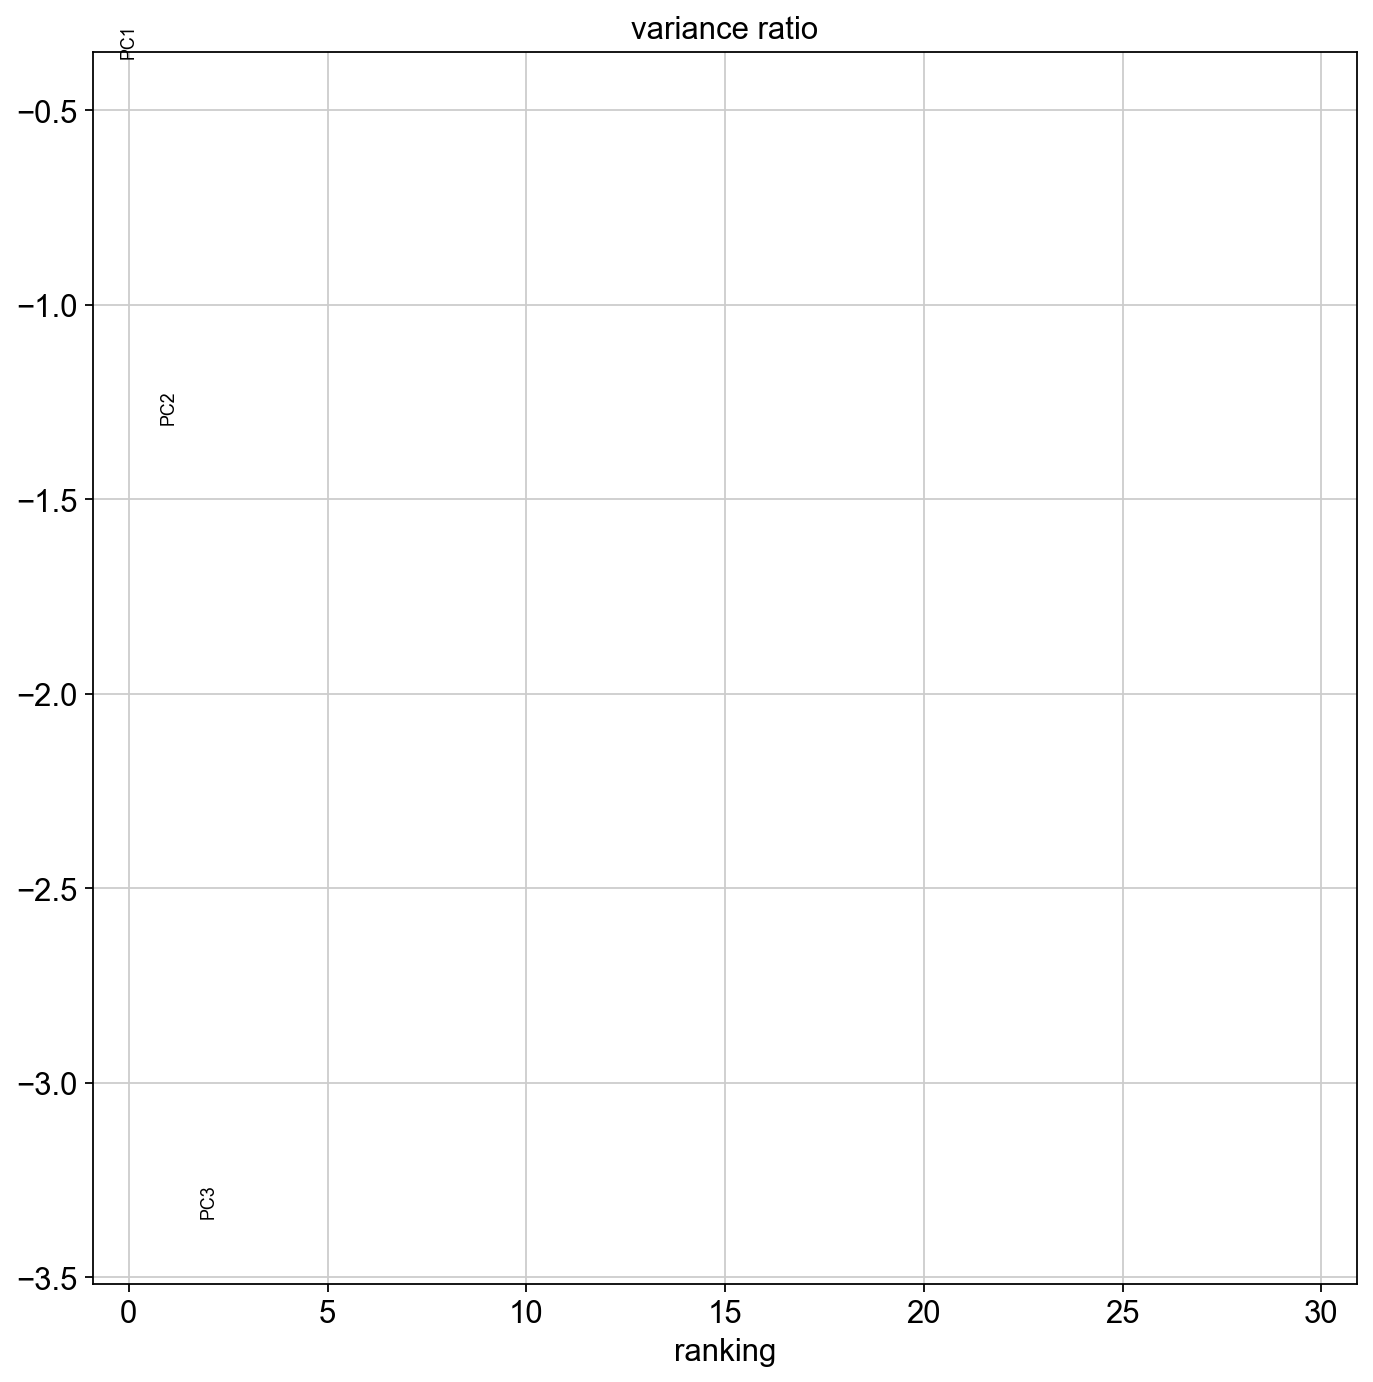

In [154]:
sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(10,10))
sc.pl.pca_variance_ratio(vdata, n_pcs=30, log=True)

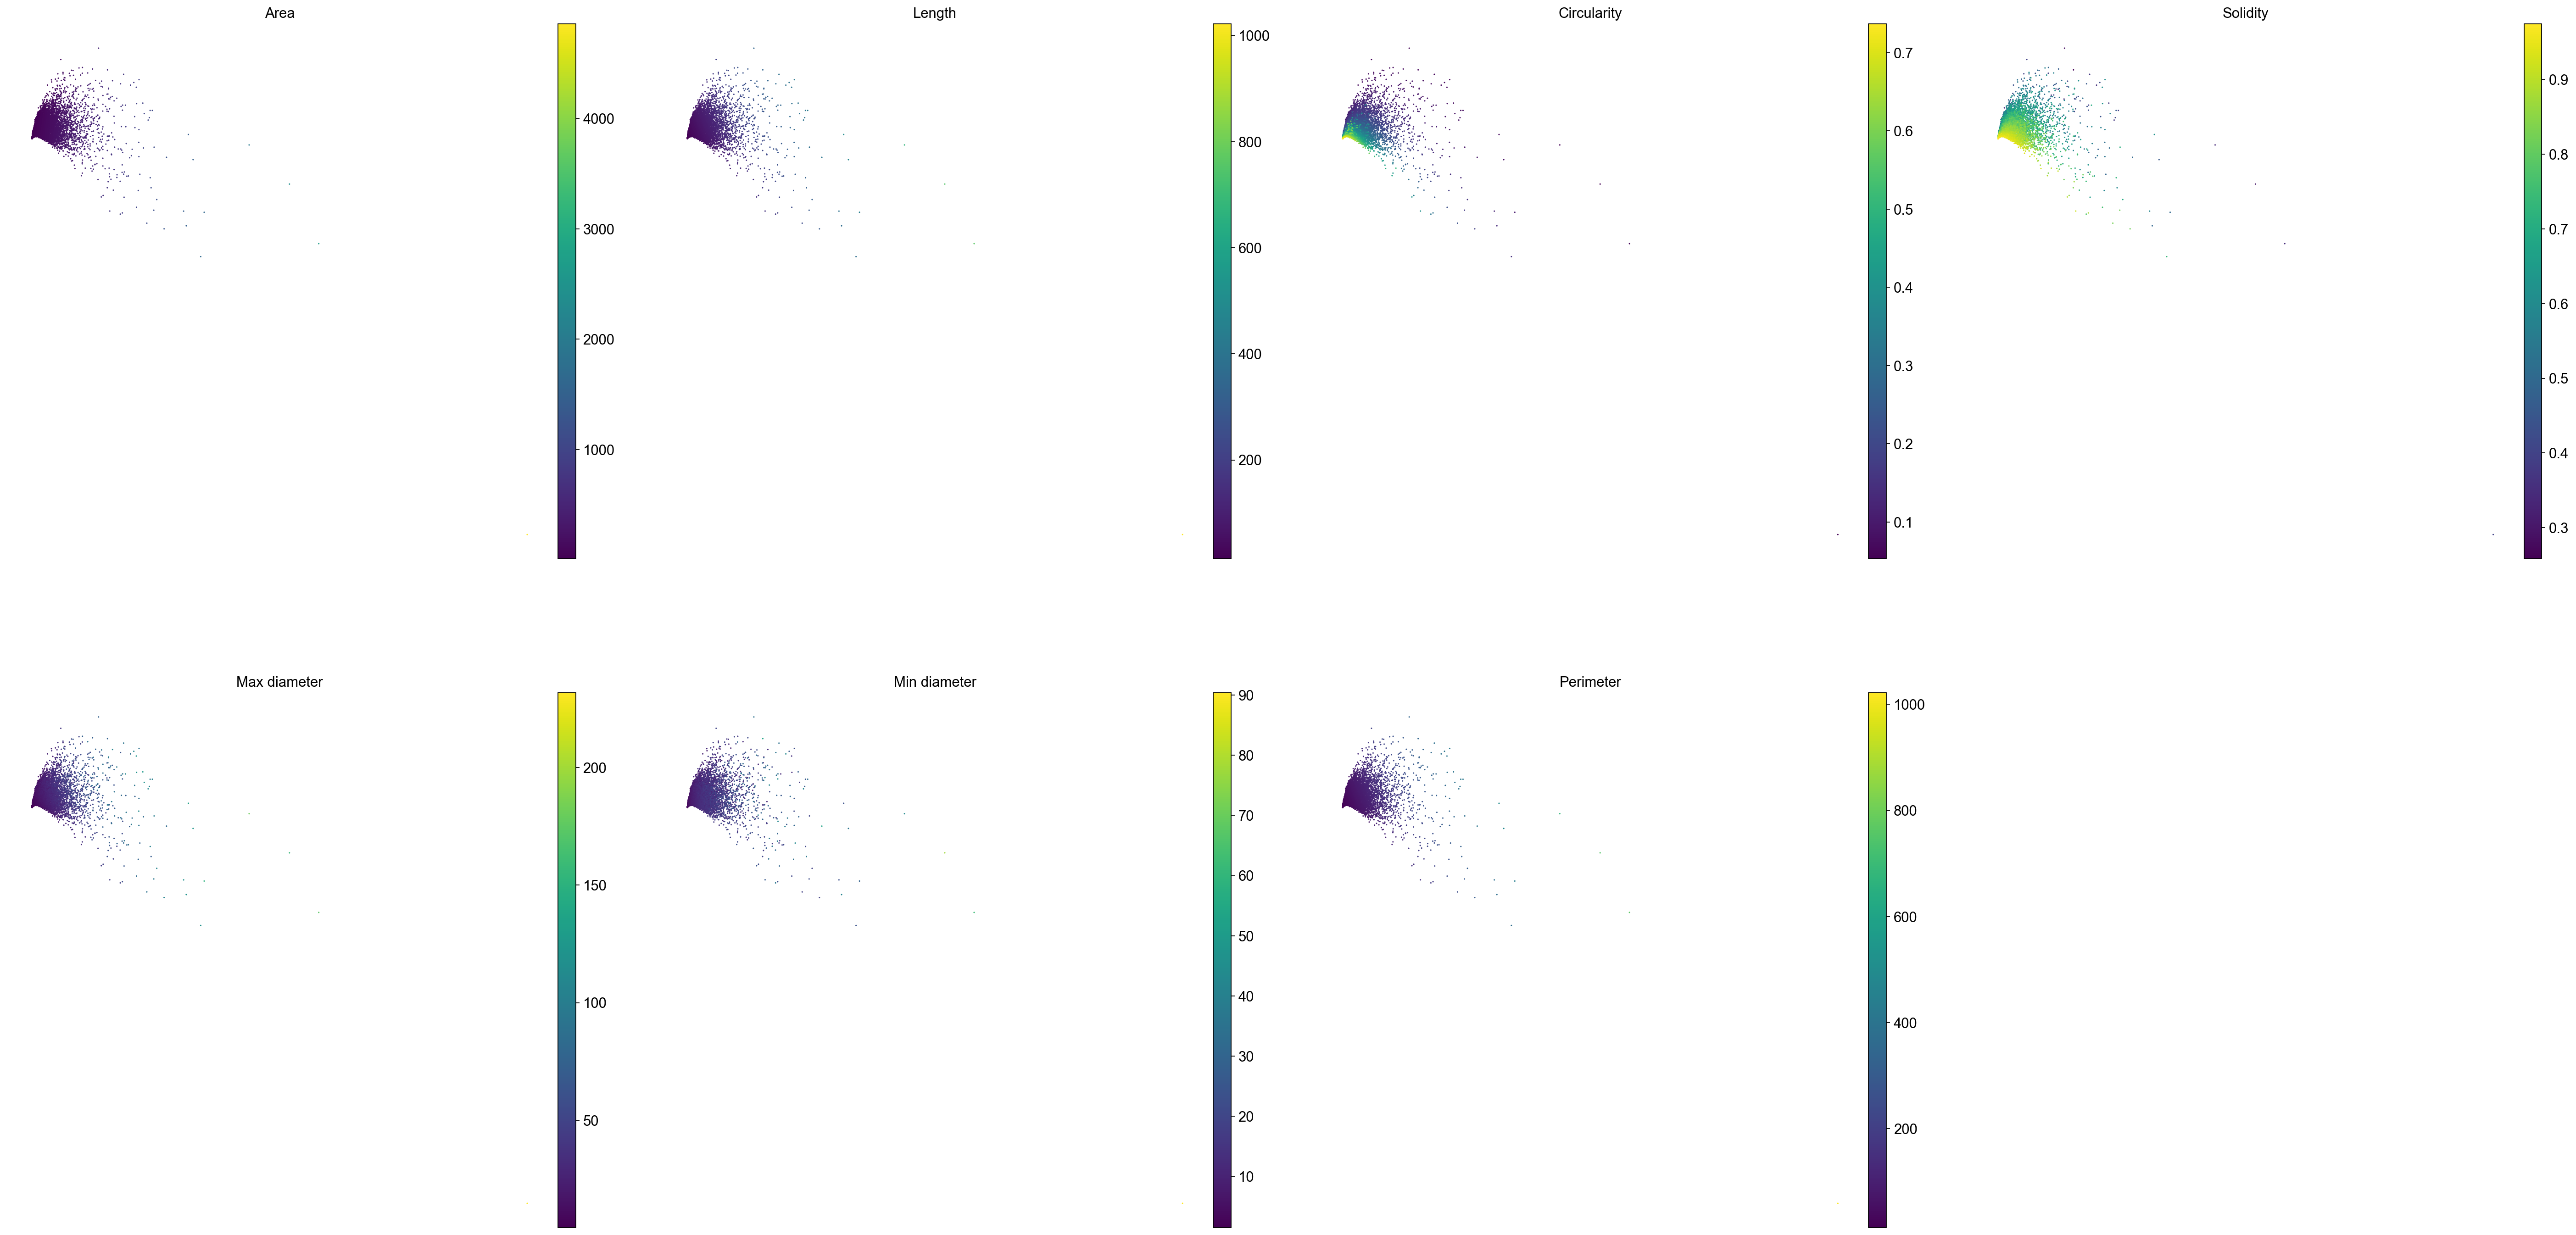

In [130]:
sc.pl.pca(vdata_temp, color=['Area', 'Length', 'Circularity', 'Solidity', 'Max diameter', 'Min diameter',
       'Perimeter'], 
          annotate_var_explained=True)

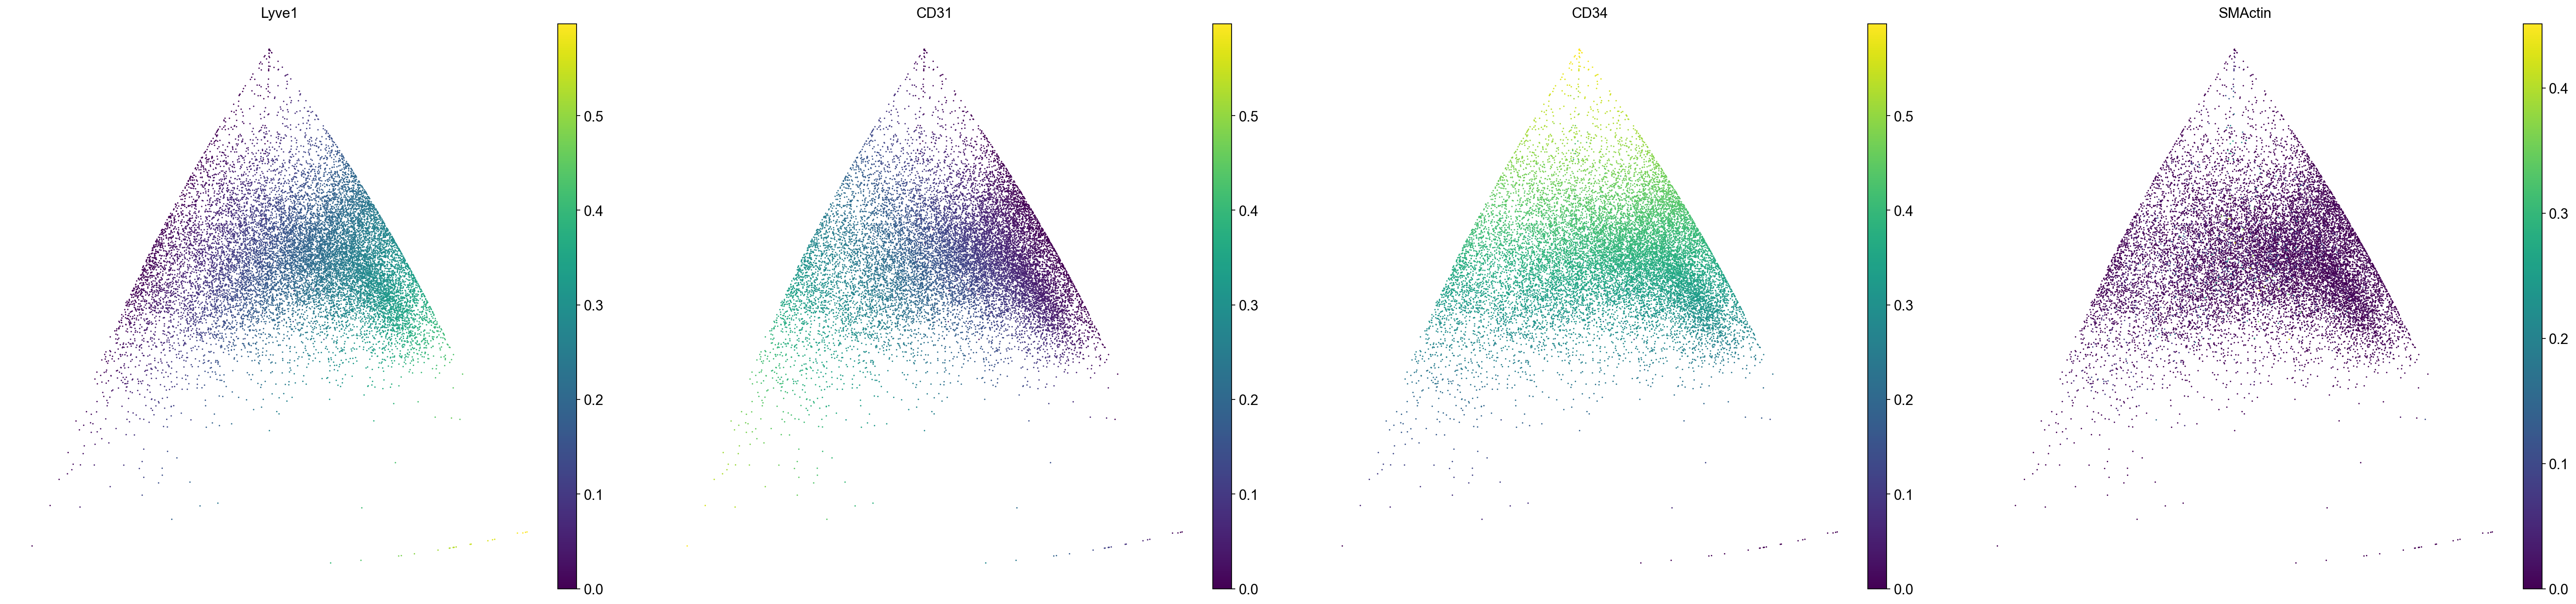

In [156]:
sc.pl.pca(vdata, color=['Lyve1', 'CD31', 'CD34', 'SMActin'], annotate_var_explained=True)

In [27]:
sc.pp.neighbors(vdata)
# sc.tl.paga(vdata, groups='Parent')
# sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(10,12))
# sc.pl.paga(vdata, fontsize=15, fontoutline= 2, layout='eq_tree', threshold=0.1, node_size_scale=8, cmap='tab20', max_edge_width=5)

In [30]:
sc.tl.umap(vdata)

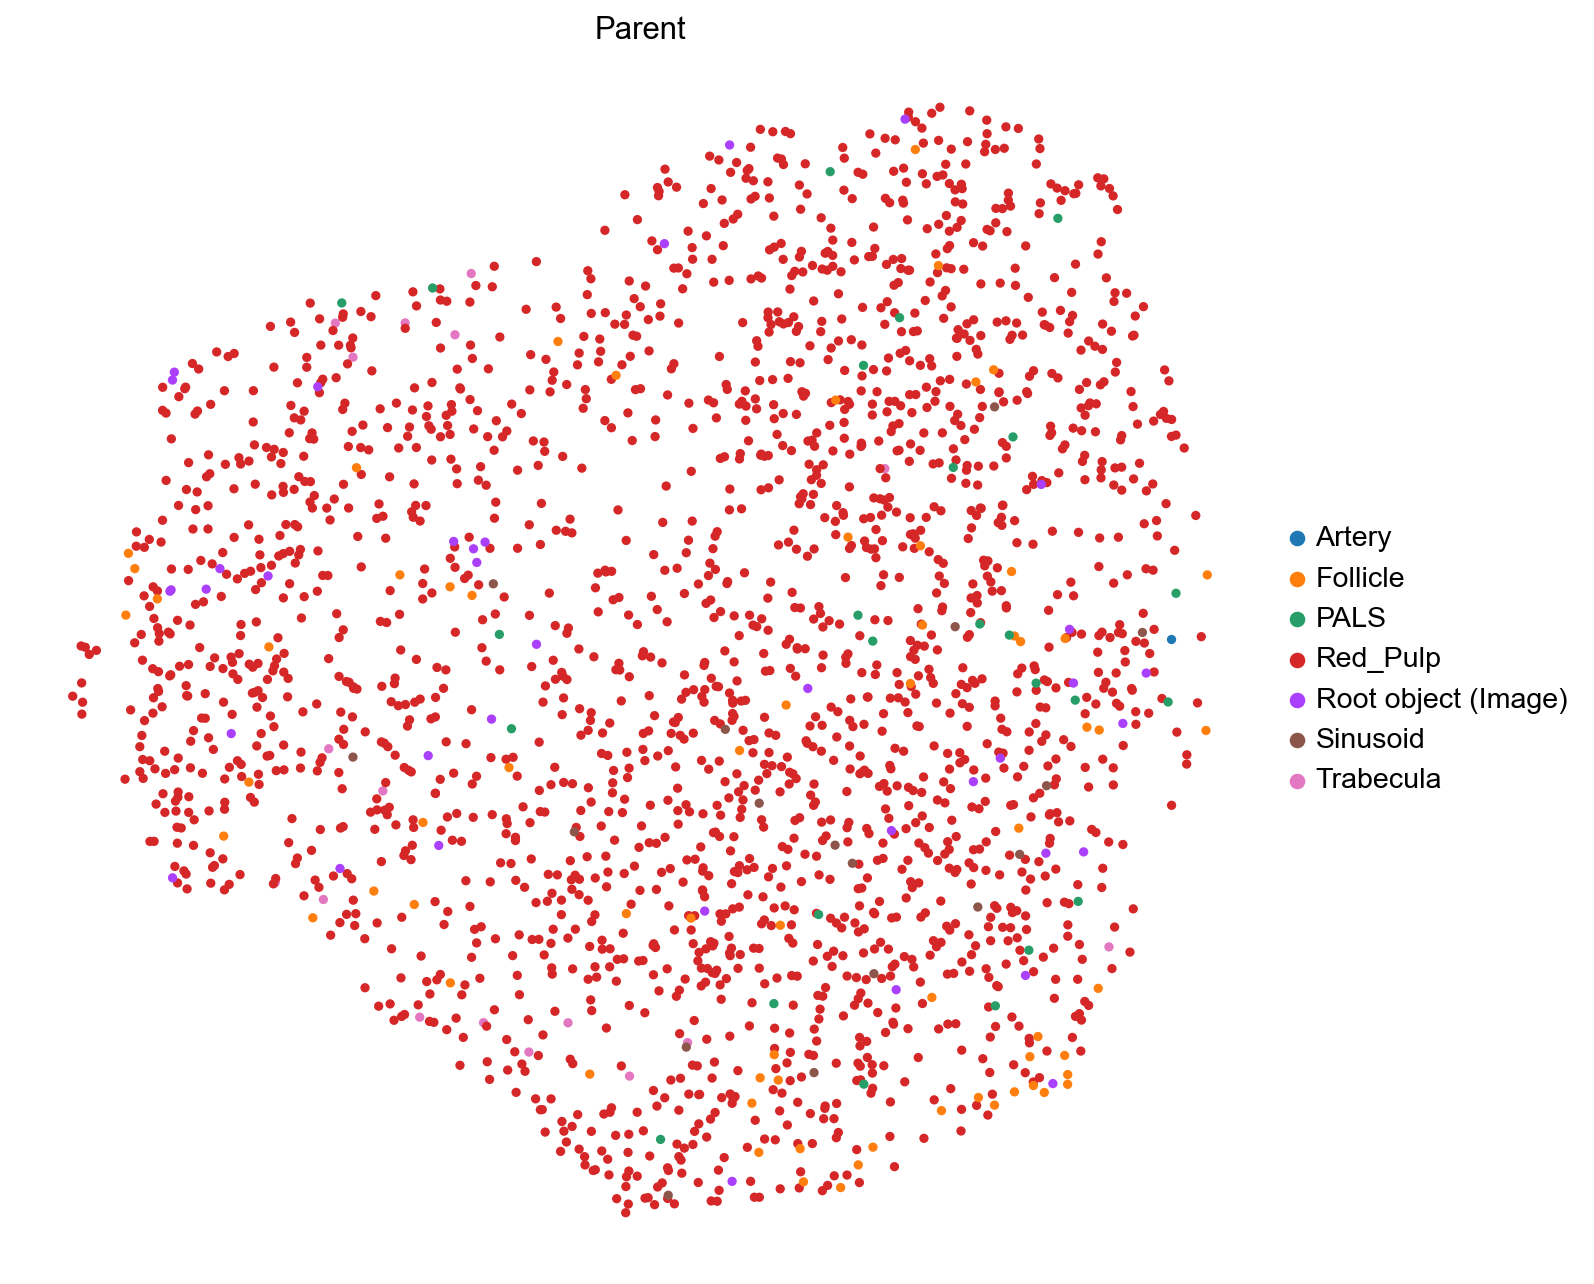

In [32]:
sc.pl.umap(vdata, color=['Parent'], size=70)

In [ ]:
sc.pl.umap(vdata, color=['Area', 'Length', 'Circularity', 'Solidity', 'Max_Diameter', 'Min_Diameter',
       'Perimeter'], size=30)

In [ ]:
sc.pl.umap(vdata, color=['Lyve1', 'CD31', 'CD34', 'SMActin', 'Vimentin'],  size=30)

In [ ]:
sc.tl.leiden(vdata, resolution=0.2, key_added='leiden_Res0.2')

In [ ]:
vdata.obs.imageid.unique()

In [ ]:
vdata_2008_3A = vdata[vdata.obs['imageid'] == '20_08_CC3A'].copy()

In [ ]:
sc.tl.dendrogram(vdata, groupby='leiden_Res0.2')

In [ ]:
sc.pl.heatmap(vdata, var_names=vdata.var_names, log=False, groupby="leiden_Res0.2", dendrogram=True, use_raw=False, swap_axes=True, cmap='coolwarm', figsize=(26, 10), show_gene_labels=True, vmin=-1.25, vmax=1.25)

In [ ]:
vdata.write_h5ad('/users/smith6jt/sscore/all_SP_vessels_markers_2025July6.h5ad')

In [ ]:
vdata = sc.read_h5ad('/users/smith6jt/sscore/all_SP_vessels_markers_2025July6.h5ad')

In [ ]:
import napari
import tifffile as tiff

marker_names = ["CD107a",
"CD1c",
"CD11c",
"CD15",
"CD163",
"CD20",
"CD21",
"CD31",
"CD34",
"CD35",
"CD3e",
"CD4",
"CD45",
"CD45RO",
"CD5",
"CD68",
"CD8",
"CollagenIV",
"DAPI",
"ECAD",
"FoxP3",
"HLADR",
"Ki67",
"Lyve1",
"Podoplanin",
"SMActin",
"Vimentin"]
marker_image = tiff.imread("C:/Users/smith6jt/Spleen/Images/20_08_CC2B.tif")

clusters_df = vdata_2008_10.obs[['leiden_Res0.2','Y_centroid','X_centroid']]
unique_clusters = clusters_df['leiden_Res0.2'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(unique_clusters)))

viewer = napari.Viewer()
viewer.add_image(marker_image, channel_axis=0, name=marker_names, rgb=False)

for i, cluster_id in enumerate(unique_clusters):
    cluster_points = clusters_df[clusters_df['leiden_Res0.2'] == cluster_id][['Y_centroid', 'X_centroid']].to_numpy()
    viewer.add_points(
        cluster_points*2.67,
        name=f'Cluster {cluster_id}',
        size=70,
        face_color=colors[i][:3],  
        opacity=0.7
    )


In [ ]:
vdata_2008_3A.obsm['X_spatial'] =vdata_2008_3A.obs[['X_centroid','Y_centroid']].values
fig,ax=plt.subplots(1,1,figsize=(12,12))
ax.invert_yaxis()
ax.axis('off')
sc.pl.scatter(vdata_2008_3A, basis='spatial',color=['leiden_Res0.2'], ax=ax, size=38, legend_fontsize='x-large',
              alpha=0.9, palette='tab20', title='Leiden Res0.2')

In [ ]:
sc.pl.umap(vdata, color=['leiden_Res0.2'],
    legend_loc="on data",
    legend_fontsize=12,
    legend_fontoutline=2,
    frameon=False, palette='tab20', add_outline=True, outline_width=(0.1, 0.05), size=25, title='Leiden Clusters')

In [ ]:
vdata.obs.to_csv('/Users/smith6jt/Spleen/SP_vessels_clusters.csv')

In [62]:
# Create comprehensive plotting DataFrame
vdata_raw = vdata.copy()
vdata_raw.X = vdata_raw.layers['raw']

plot_df = pd.DataFrame({
    'Area': vdata_raw[:, 'Area'].X.flatten(),
    'Lyve1': vdata_raw[:, 'Lyve1'].X.flatten(),
    'CD31': vdata_raw[:, 'CD31'].X.flatten(),
    'CD34': vdata_raw[:, 'CD34'].X.flatten(),
    'SMActin': vdata_raw[:, 'SMActin'].X.flatten(),
    'Min_Diameter': vdata_raw[:, 'Min_Diameter'].X.flatten(),
    'imageid': vdata_raw.obs['imageid'],
    'leiden_cluster': vdata_raw.obs['leiden_Res0.2'],
    'Parent': vdata_raw.obs['Parent']
})

# Multiple plotting options
fig, axes = plt.subplots(1, 2, figsize=(24, 14))

# Plot 1: Area vs Lyve1 by image
sns.scatterplot(data=plot_df, x='Min_Diameter', y='CD34', hue='imageid', 
                palette='tab20', s=30, alpha=0.6, ax=axes[0])
axes[0].set_title('Area vs Lyve1 by Image')

# Plot 2: Area vs Lyve1 by cluster
sns.scatterplot(data=plot_df, x='Min_Diameter', y='CD34', hue='leiden_cluster', 
                palette='turbo', s=30, alpha=0.6, ax=axes[1])
axes[1].set_title('Area vs Lyve1 by Cluster')


plt.tight_layout()
plt.show()

KeyError: 'raw'

In [73]:
vdata.var_names

Index(['CD1c', 'CD3e', 'CD4', 'CD5', 'CD8', 'CD11c', 'CD15', 'CD20', 'CD21',
       'CD31', 'CD34', 'CD35', 'CD44', 'CD45', 'CD45RO', 'CD68', 'CD107a',
       'CD163', 'CollagenIV', 'DAPI', 'FoxP3', 'HLADR', 'Ki67', 'Lyve1',
       'Podoplanin', 'SMActin', 'Vimentin', 'ECAD'],
      dtype='object')

In [74]:
# Complete PCA Analysis Including Shape, Marker, and Categorical Data

# Create a comprehensive dataset combining obs (shape + categorical) and var (markers)
vdata_pca = vdata.copy()

vdata_pca = vdata_pca[:, ['CD31', 'CD34', 'Lyve1', 'SMActin']]

# Extract shape measurements from obs (numerical)
shape_features = ['Area', 'Length', 'Circularity', 'Min diameter']
shape_data = vdata_pca.obs[shape_features].values

# Extract categorical features from obs
categorical_features = ['Parent']  # Add other categorical columns as needed
print(f"Available categorical features: {vdata_pca.obs.select_dtypes(include=['object', 'category']).columns.tolist()}")

# One-hot encode categorical variables
from sklearn.preprocessing import LabelEncoder
import pandas as pd

categorical_data_list = []
categorical_feature_names = []

for cat_feature in categorical_features:
    if cat_feature in vdata_pca.obs.columns:
        # One-hot encoding for categorical variables
        cat_dummies = pd.get_dummies(vdata_pca.obs[cat_feature], prefix=cat_feature)
        categorical_data_list.append(cat_dummies.values)
        categorical_feature_names.extend(cat_dummies.columns.tolist())

# Combine all categorical data
if categorical_data_list:
    categorical_data = np.concatenate(categorical_data_list, axis=1)
else:
    categorical_data = np.empty((vdata_pca.shape[0], 0))

# Extract marker data (already in .X)
marker_data = vdata_pca.X.copy()
if 'scaled' in vdata_pca.layers:
    marker_data = vdata_pca.layers['scaled'].copy()

# Combine all data: shape + categorical + markers
combined_data = np.concatenate([shape_data, categorical_data, marker_data], axis=1)

# Create comprehensive feature names
shape_feature_names = shape_features
marker_feature_names = vdata_pca.var_names.tolist()
all_feature_names = shape_feature_names + categorical_feature_names + marker_feature_names

print(f"Shape features ({len(shape_feature_names)}): {shape_feature_names}")
print(f"Categorical features ({len(categorical_feature_names)}): {categorical_feature_names}")
print(f"Marker features ({len(marker_feature_names)}): {marker_feature_names}")
print(f"Total features: {len(all_feature_names)}")

Available categorical features: ['imageid', 'Parent']
Shape features (4): ['Area', 'Length', 'Circularity', 'Min diameter']
Categorical features (5): ['Parent_Border', 'Parent_Capsule', 'Parent_Follicle', 'Parent_Paracortex', 'Parent_Sinus']
Marker features (4): ['CD31', 'CD34', 'Lyve1', 'SMActin']
Total features: 13


In [68]:
!pip install adjustText

  Using cached adjustText-1.3.0-py3-none-any.whl.metadata (3.1 kB)
Using cached adjustText-1.3.0-py3-none-any.whl (13 kB)


In [75]:
from adjustText import adjust_text

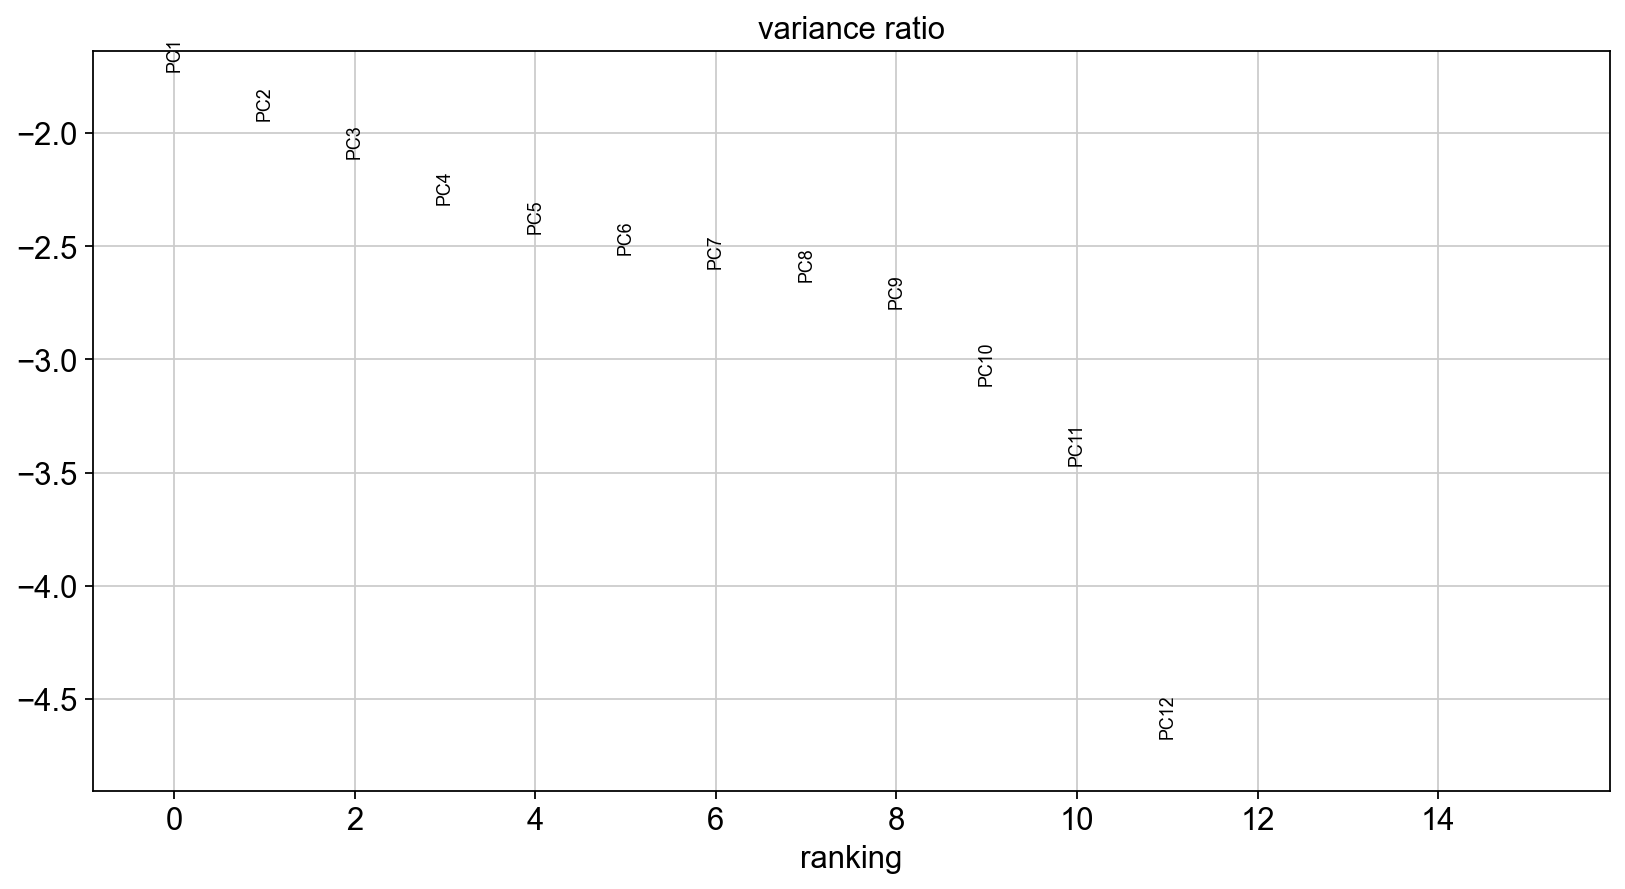


PCA Loadings (Variable Contributions):
                        PC1       PC2       PC3       PC4       PC5       PC6  \
Area              -0.099552 -0.042938 -0.015670 -0.332202  0.412620  0.015000   
Length             0.548692 -0.191930 -0.109697 -0.247346 -0.081299 -0.098541   
Circularity       -0.384826  0.200770 -0.107974 -0.269395  0.011759 -0.251569   
Min diameter       0.512300 -0.130702 -0.152361 -0.296518 -0.101780 -0.234963   
Parent_Border     -0.020111 -0.408417  0.067394 -0.266069  0.577866  0.127275   
Parent_Capsule    -0.043254 -0.260628 -0.154026 -0.010579 -0.418986  0.715860   
Parent_Follicle   -0.148925 -0.275382  0.381693 -0.090583 -0.463779 -0.435516   
Parent_Paracortex  0.172727  0.682368 -0.152468  0.001632  0.035101  0.007848   
Parent_Sinus      -0.099446 -0.264427 -0.131773  0.502977  0.145431 -0.306928   
CD31               0.379821  0.118373  0.249126  0.296350  0.177763  0.103263   
CD34               0.216361  0.024084  0.603936  0.232234  0.089970  

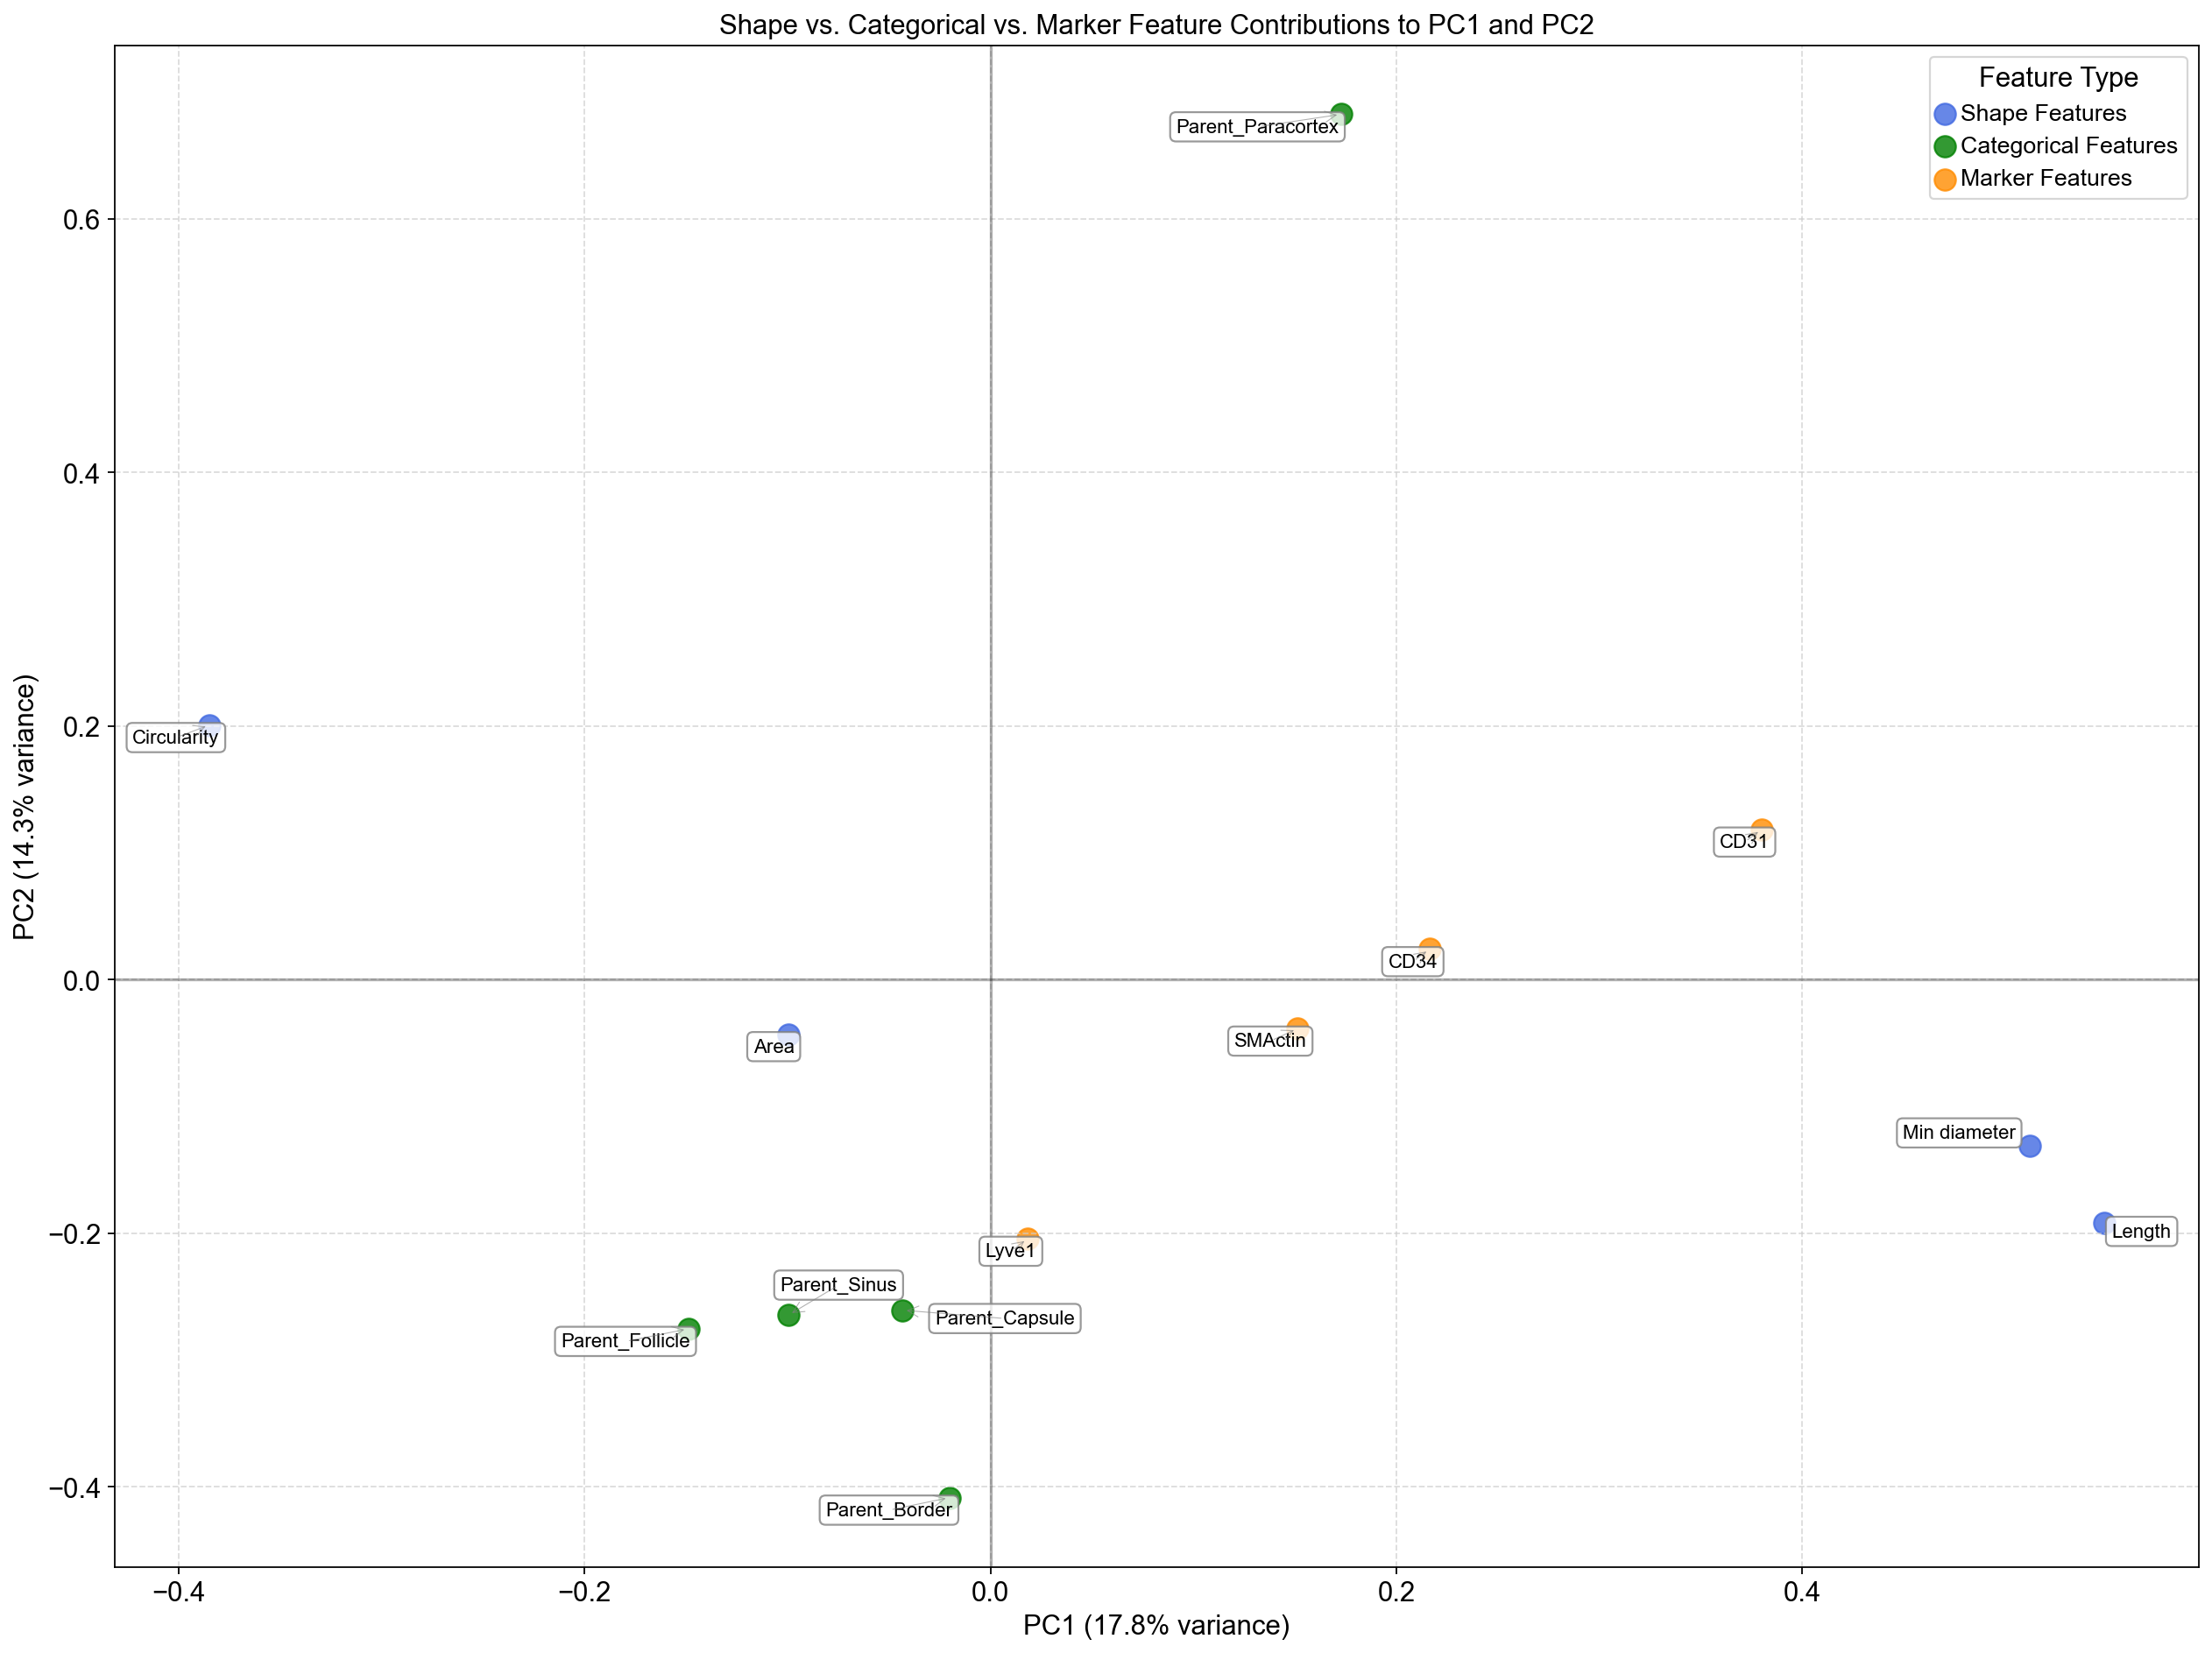

In [76]:
# Create a new AnnData object with combined data
combined_adata = ad.AnnData(X=combined_data)
combined_adata.obs = vdata_pca.obs.copy()
combined_adata.var_names = all_feature_names

# Standardize the combined data for PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
combined_adata.X = scaler.fit_transform(combined_adata.X)

# Run PCA
sc.pp.pca(combined_adata, svd_solver='arpack', n_comps=min(15, combined_adata.shape[1]-1))

# Plot variance ratio
sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(12, 6))
sc.pl.pca_variance_ratio(combined_adata, n_pcs=15, log=True)

# Extract PCA loadings (variable contributions to each PC)
loadings = pd.DataFrame(
    combined_adata.varm['PCs'], 
    index=combined_adata.var_names, 
    columns=[f'PC{i+1}' for i in range(combined_adata.varm['PCs'].shape[1])]
)

# Add feature type column
def get_feature_type(feature_name):
    if feature_name in shape_feature_names:
        return 'Shape'
    elif feature_name in categorical_feature_names:
        return 'Categorical'
    else:
        return 'Marker'

loadings['Type'] = [get_feature_type(feature) for feature in loadings.index]

print("\nPCA Loadings (Variable Contributions):")
print(loadings.head(15))

# Visualize the loadings for the first two PCs with feature types highlighted
# Visualize the loadings for the first two PCs with feature types highlighted
plt.figure(figsize=(16, 12))
colors = {'Shape': 'royalblue', 'Categorical': 'green', 'Marker': 'darkorange'}

# Plot the points first
for feature_type in ['Shape', 'Categorical', 'Marker']:
    subset = loadings[loadings['Type'] == feature_type]
    if len(subset) > 0:
        plt.scatter(subset['PC1'], subset['PC2'], s=120, 
                   label=f'{feature_type} Features', 
                   alpha=0.8, color=colors[feature_type])

plt.grid(True, linestyle='--', alpha=0.7)

# Create annotations list for adjustText
texts = []
for i, row in loadings.iterrows():
    # Create text annotations without positioning them yet
    text = plt.annotate(i, (row['PC1'], row['PC2']), 
                       fontsize=10, ha='center', va='center',
                       bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
    texts.append(text)

# Adjust text positions to avoid overlaps
adjust_text(texts, 
           arrowprops=dict(arrowstyle='->', color='gray', alpha=0.6, lw=0.5),
           expand_points=(1.2, 1.2),  # Expand around points
           expand_text=(1.1, 1.1),   # Expand around text
           force_points=0.5,         # Force to avoid points
           force_text=0.8)           # Force to avoid text overlap

# Add reference lines
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.xlabel(f'PC1 ({combined_adata.uns["pca"]["variance_ratio"][0]:.1%} variance)')
plt.ylabel(f'PC2 ({combined_adata.uns["pca"]["variance_ratio"][1]:.1%} variance)')
plt.title('Shape vs. Categorical vs. Marker Feature Contributions to PC1 and PC2')
plt.legend(title='Feature Type', fontsize=12)
plt.tight_layout()
plt.show()

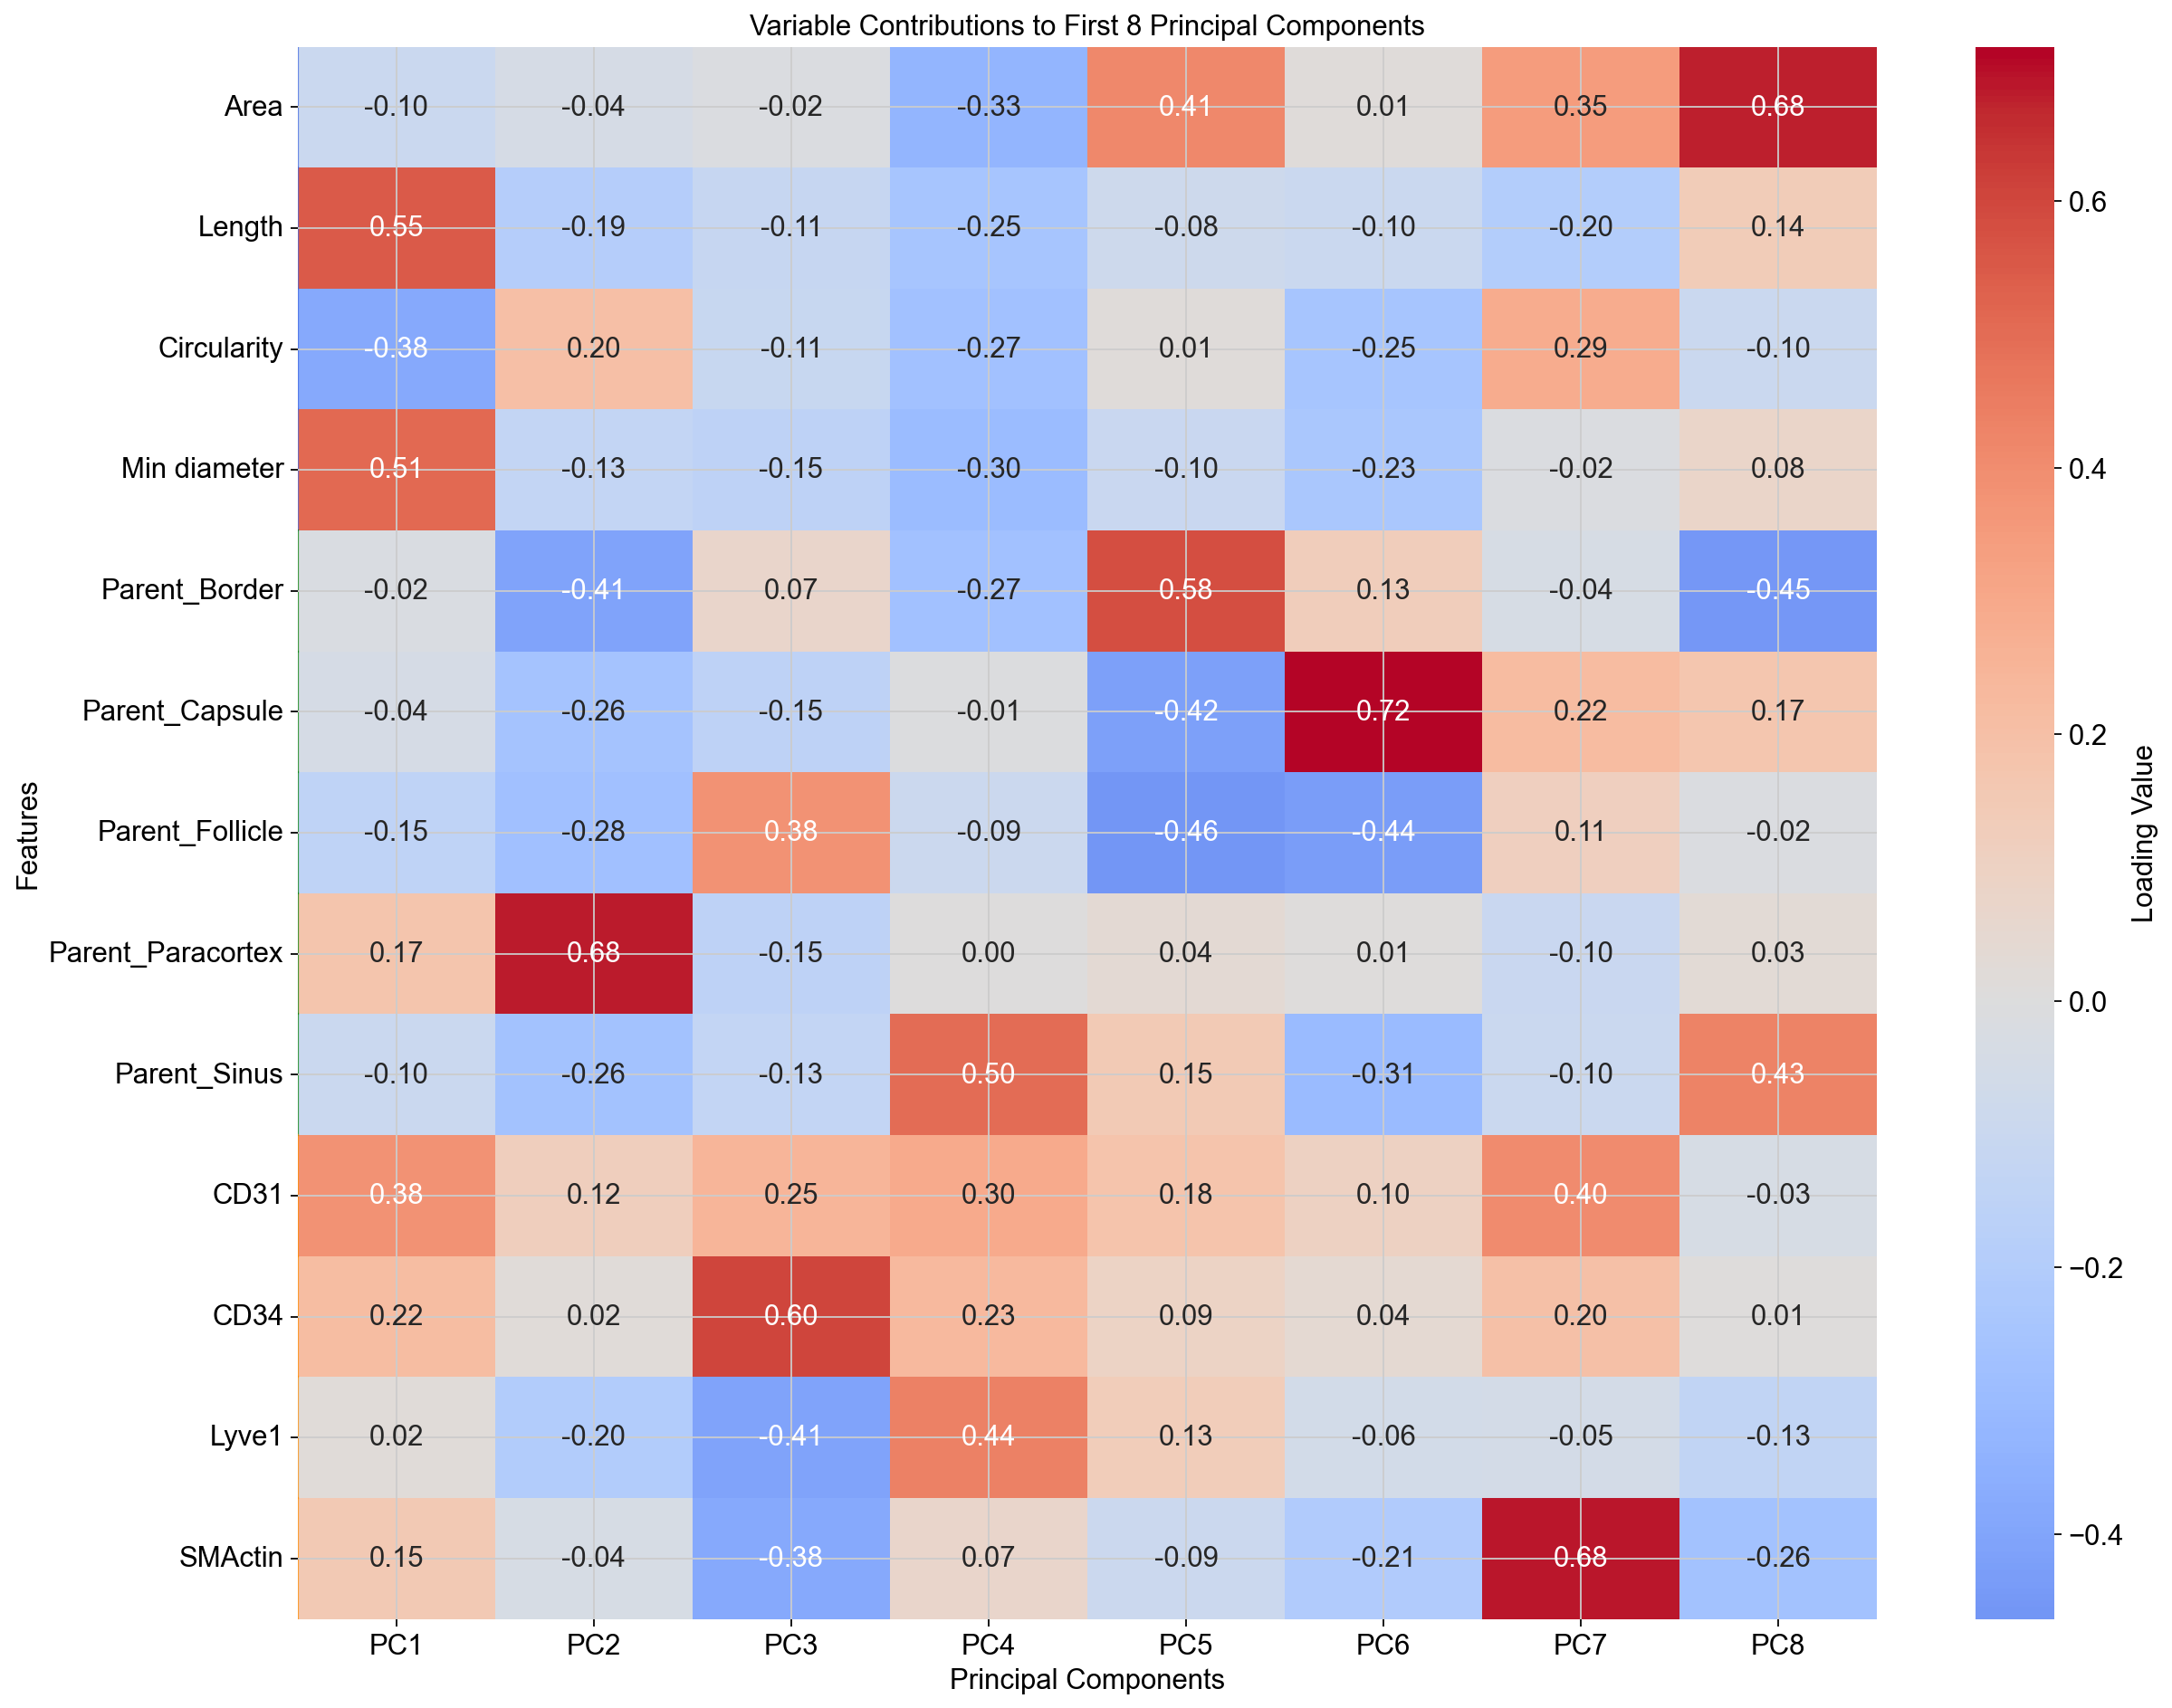

In [77]:
# Heatmap of loadings for first 8 PCs
plt.figure(figsize=(16, 12))
loadings_for_heatmap = loadings.iloc[:, :8]  # First 8 PCs

# Create the heatmap
sns.heatmap(loadings_for_heatmap, annot=True, cmap='coolwarm', center=0, fmt=".2f", 
            cbar_kws={'label': 'Loading Value'})
plt.title('Variable Contributions to First 8 Principal Components')
plt.ylabel('Features')
plt.xlabel('Principal Components')

# Add colored bars for feature types
for i, (idx, row) in enumerate(loadings.iterrows()):
    plt.gca().add_patch(plt.Rectangle((-0.5, i), 0.5, 1, 
                                     color=colors[row['Type']], alpha=0.7))

plt.tight_layout()
plt.show()

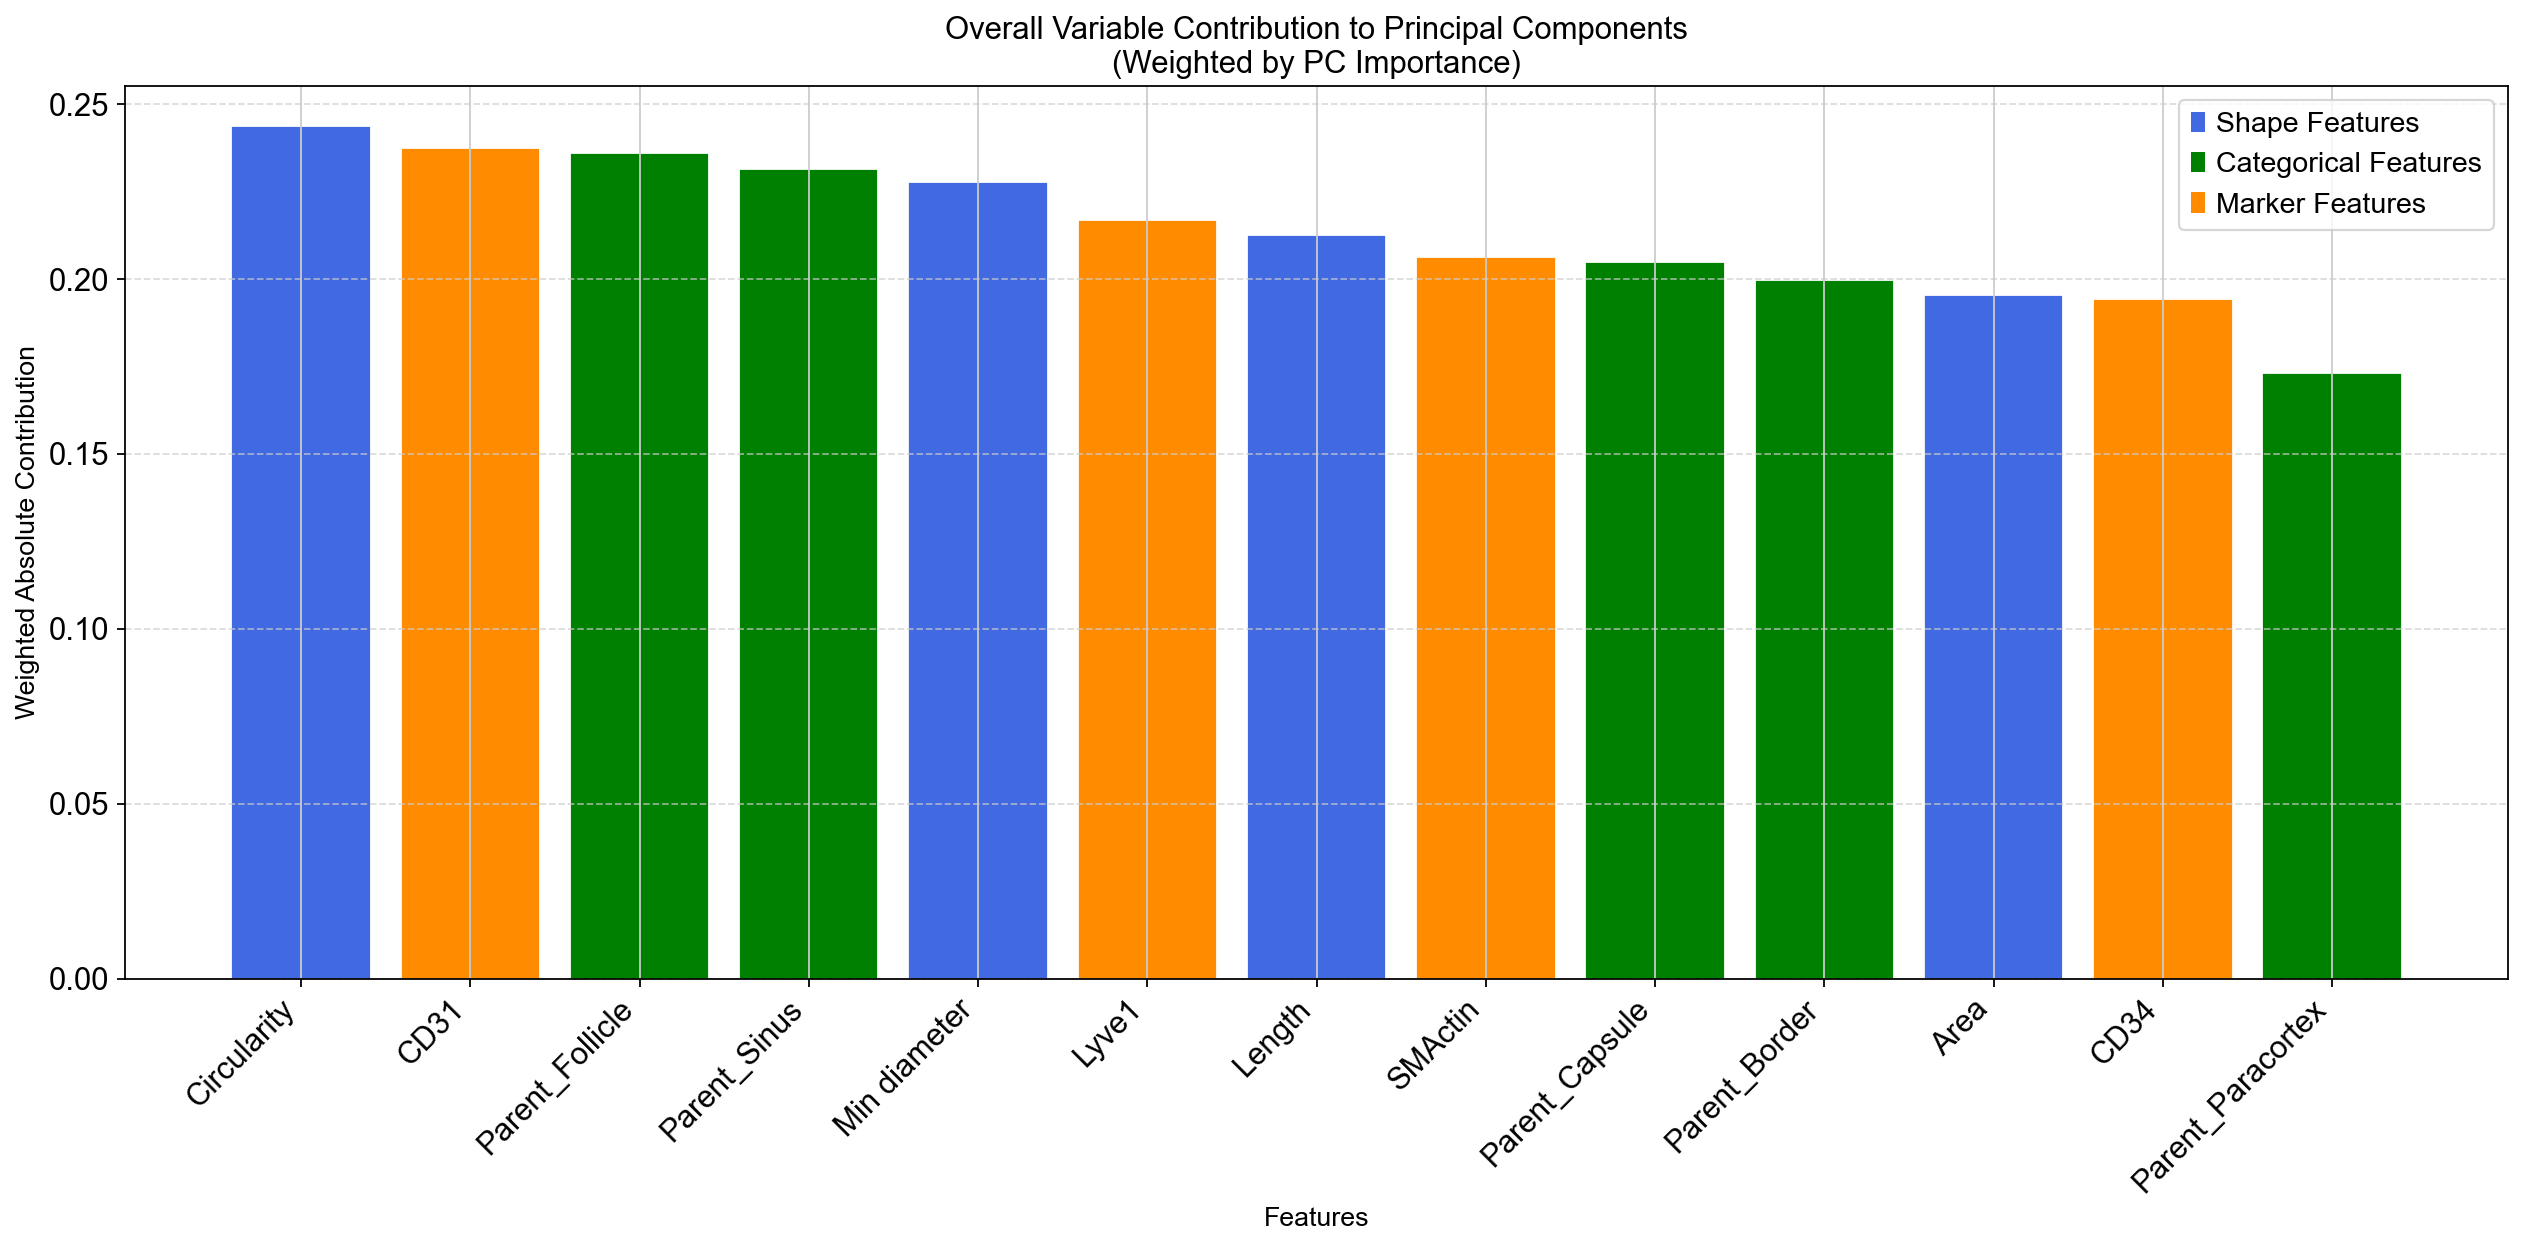

In [78]:
# Calculate weighted contributions
explained_variance_ratio = combined_adata.uns['pca']['variance_ratio']
weighted_loadings = loadings.copy()
for i in range(loadings.shape[1]-1):  # -1 to exclude Type column
    weighted_loadings.iloc[:, i] = np.abs(loadings.iloc[:, i]) * explained_variance_ratio[i]

# Sum up the absolute contributions across all PCs
total_contribution = weighted_loadings.iloc[:, :-1].sum(axis=1)  # Exclude Type column
total_contribution = total_contribution.sort_values(ascending=False)

# Plot the total contribution of each variable
plt.figure(figsize=(16, 8))
bars = plt.bar(range(len(total_contribution)), total_contribution.values)

# Color the bars by feature type
for i, (feature, value) in enumerate(total_contribution.items()):
    feature_type = get_feature_type(feature)
    bars[i].set_color(colors[feature_type])

plt.title('Overall Variable Contribution to Principal Components\n(Weighted by PC Importance)', fontsize=14)
plt.ylabel('Weighted Absolute Contribution', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.xticks(range(len(total_contribution)), total_contribution.index, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors['Shape'], label='Shape Features'),
    Patch(facecolor=colors['Categorical'], label='Categorical Features'),
    Patch(facecolor=colors['Marker'], label='Marker Features')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
print("\nTop 15 Contributing Features:")
for i, (feature, value) in enumerate(total_contribution.head(15).items()):
    feature_type = get_feature_type(feature)
    print(f"{i+1:2d}. {feature:25s} ({feature_type:11s}): {value:.4f}")

# Show feature type distribution in top contributors
top_15_types = [get_feature_type(f) for f in total_contribution.head(15).index]
print(f"\nTop 15 feature types:")
print(f"Shape: {top_15_types.count('Shape')}")
print(f"Categorical: {top_15_types.count('Categorical')}")
print(f"Marker: {top_15_types.count('Marker')}")

# Store the combined analysis results
vdata.uns['pca_combined'] = {
    'loadings': loadings,
    'total_contribution': total_contribution,
    'explained_variance_ratio': explained_variance_ratio,
    'feature_types': {
        'shape': shape_feature_names,
        'categorical': categorical_feature_names,
        'marker': marker_feature_names
    }
}


Top 15 Contributing Features:
 1. Circularity               (Shape      ): 0.1983
 2. Parent_Red_Pulp           (Categorical): 0.1936
 3. CD31                      (Marker     ): 0.1884
 4. Parent_Sinusoid           (Categorical): 0.1839
 5. Parent_Border             (Categorical): 0.1824
 6. Lyve1                     (Marker     ): 0.1798
 7. CD34                      (Marker     ): 0.1789
 8. Area                      (Shape      ): 0.1686
 9. Parent_Trabecula          (Categorical): 0.1674
10. SMActin                   (Marker     ): 0.1669
11. Min diameter              (Shape      ): 0.1657
12. Parent_Peripheral_White_Pulp (Categorical): 0.1545
13. Length                    (Shape      ): 0.1508
14. Parent_PALS               (Categorical): 0.1506
15. Parent_Follicle           (Categorical): 0.1386

Top 15 feature types:
Shape: 4
Categorical: 7
Marker: 4


In [ ]:
# Complete PCA Analysis Including Shape Measurements from .obs and Marker Intensities from .var

# Create a comprehensive dataset combining obs (shape) and var (markers)
vdata_pca = vdata.copy()

# Extract shape measurements from obs
shape_features = ['Area', 'Length', 'Circularity',  'Min diameter']
shape_data = vdata_pca.obs[shape_features].values

# Extract marker data (already in .X)
marker_data = vdata_pca.X.copy()
if 'scaled' in vdata_pca.layers:
    marker_data = vdata_pca.layers['scaled'].copy()

# Combine shape and marker data
combined_data = np.concatenate([shape_data, marker_data], axis=1)

# Create feature names
shape_feature_names = shape_features
marker_feature_names = vdata_pca.var_names.tolist()
all_feature_names = shape_feature_names + marker_feature_names

print(f"Shape features: {shape_feature_names}")
print(f"Marker features: {marker_feature_names}")
print(f"Total features: {len(all_feature_names)}")

Shape features: ['Area', 'Perimeter', 'Length', 'Circularity', 'Solidity', 'Max diameter', 'Min diameter']
Marker features: ['CD31', 'CD34', 'Lyve1', 'SMActin']
Total features: 11


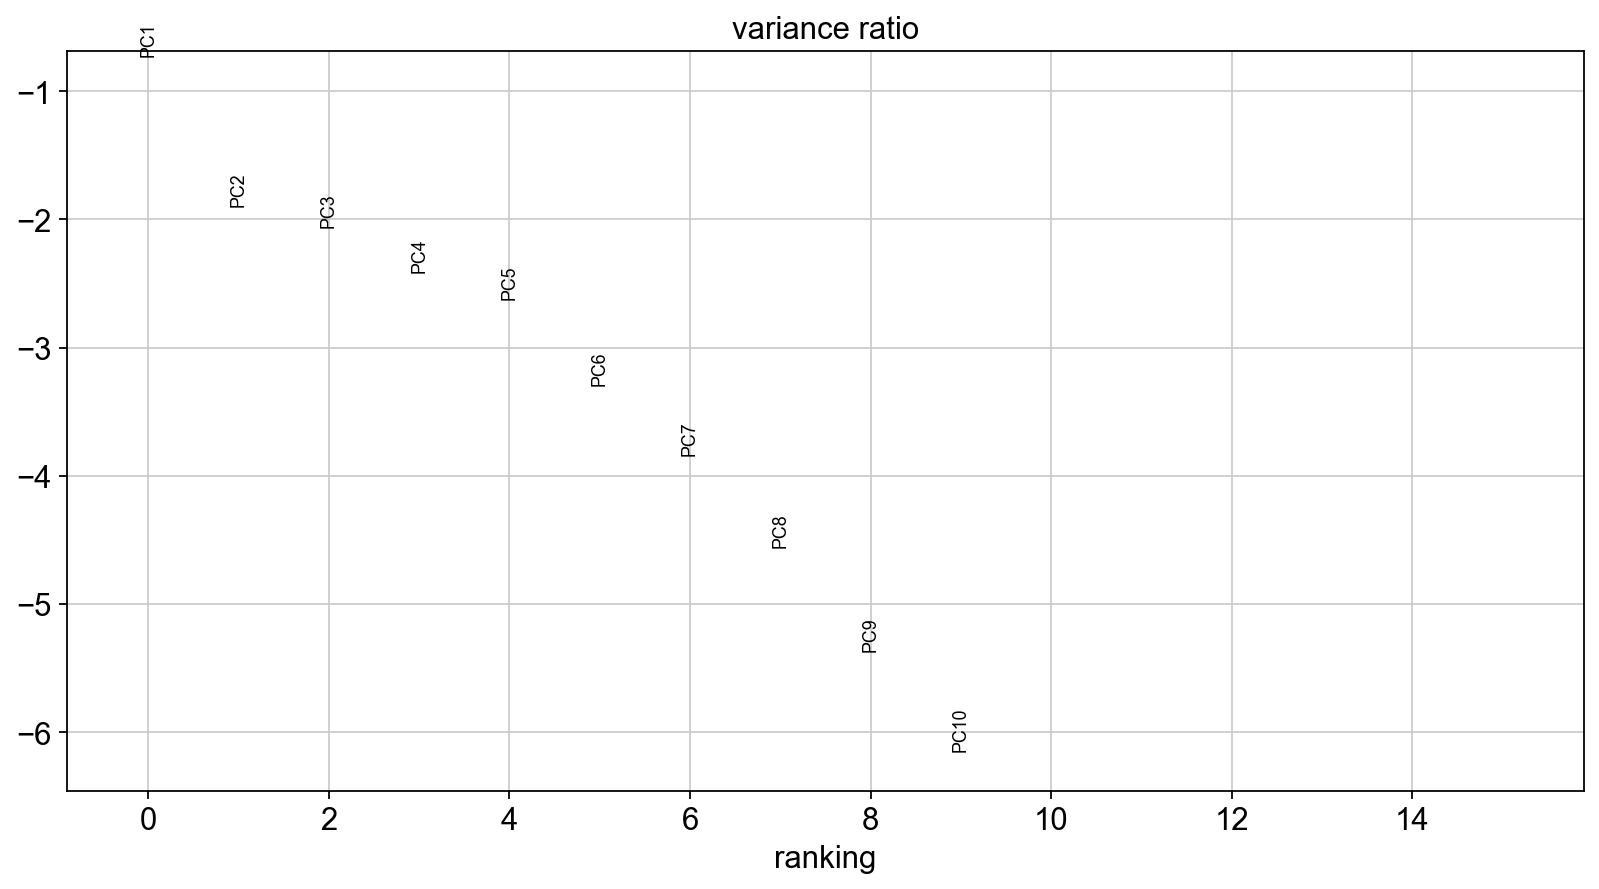


PCA Loadings (Variable Contributions):
                   PC1       PC2       PC3       PC4       PC5       PC6  \
Area          0.397904  0.211088  0.011771 -0.066379 -0.185887 -0.153156   
Perimeter     0.428255  0.060610  0.025560 -0.032931 -0.058996 -0.034580   
Length        0.428255  0.060611  0.025561 -0.032931 -0.058997 -0.034581   
Circularity  -0.302524  0.451341  0.002861 -0.094602 -0.342339 -0.178571   
Solidity     -0.263217  0.513000 -0.020604 -0.085823 -0.389467 -0.138173   
Max diameter  0.413323  0.096133  0.036274 -0.046288 -0.069728 -0.063142   
Min diameter  0.372544  0.200917 -0.003463 -0.045878 -0.165115  0.024147   
CD31          0.026470  0.468407 -0.315402  0.052070  0.743209 -0.352071   
CD34          0.003079  0.441234  0.562208  0.140175  0.253487  0.631718   
Lyve1        -0.042144 -0.123266  0.746985  0.117383  0.085818 -0.627622   

                   PC7       PC8       PC9      PC10    Type  
Area         -0.123868  0.159088  0.830667 -0.062444   Shape

In [ ]:
# Create a new AnnData object with combined data
combined_adata = ad.AnnData(X=combined_data)
combined_adata.obs = vdata_pca.obs.copy()
combined_adata.var_names = all_feature_names

# Standardize the combined data for PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
combined_adata.X = scaler.fit_transform(combined_adata.X)

# Run PCA
sc.pp.pca(combined_adata, svd_solver='arpack', n_comps=min(15, combined_adata.shape[1]-1))

# Plot variance ratio
sc.settings.set_figure_params(facecolor="white", frameon=False, figsize=(12, 6))
sc.pl.pca_variance_ratio(combined_adata, n_pcs=15, log=True)

# Extract PCA loadings (variable contributions to each PC)
loadings = pd.DataFrame(
    combined_adata.varm['PCs'], 
    index=combined_adata.var_names, 
    columns=[f'PC{i+1}' for i in range(combined_adata.varm['PCs'].shape[1])]
)

# Add feature type column
loadings['Type'] = ['Shape' if feature in shape_feature_names else 'Marker' for feature in loadings.index]

print("\nPCA Loadings (Variable Contributions):")
print(loadings.head(10))

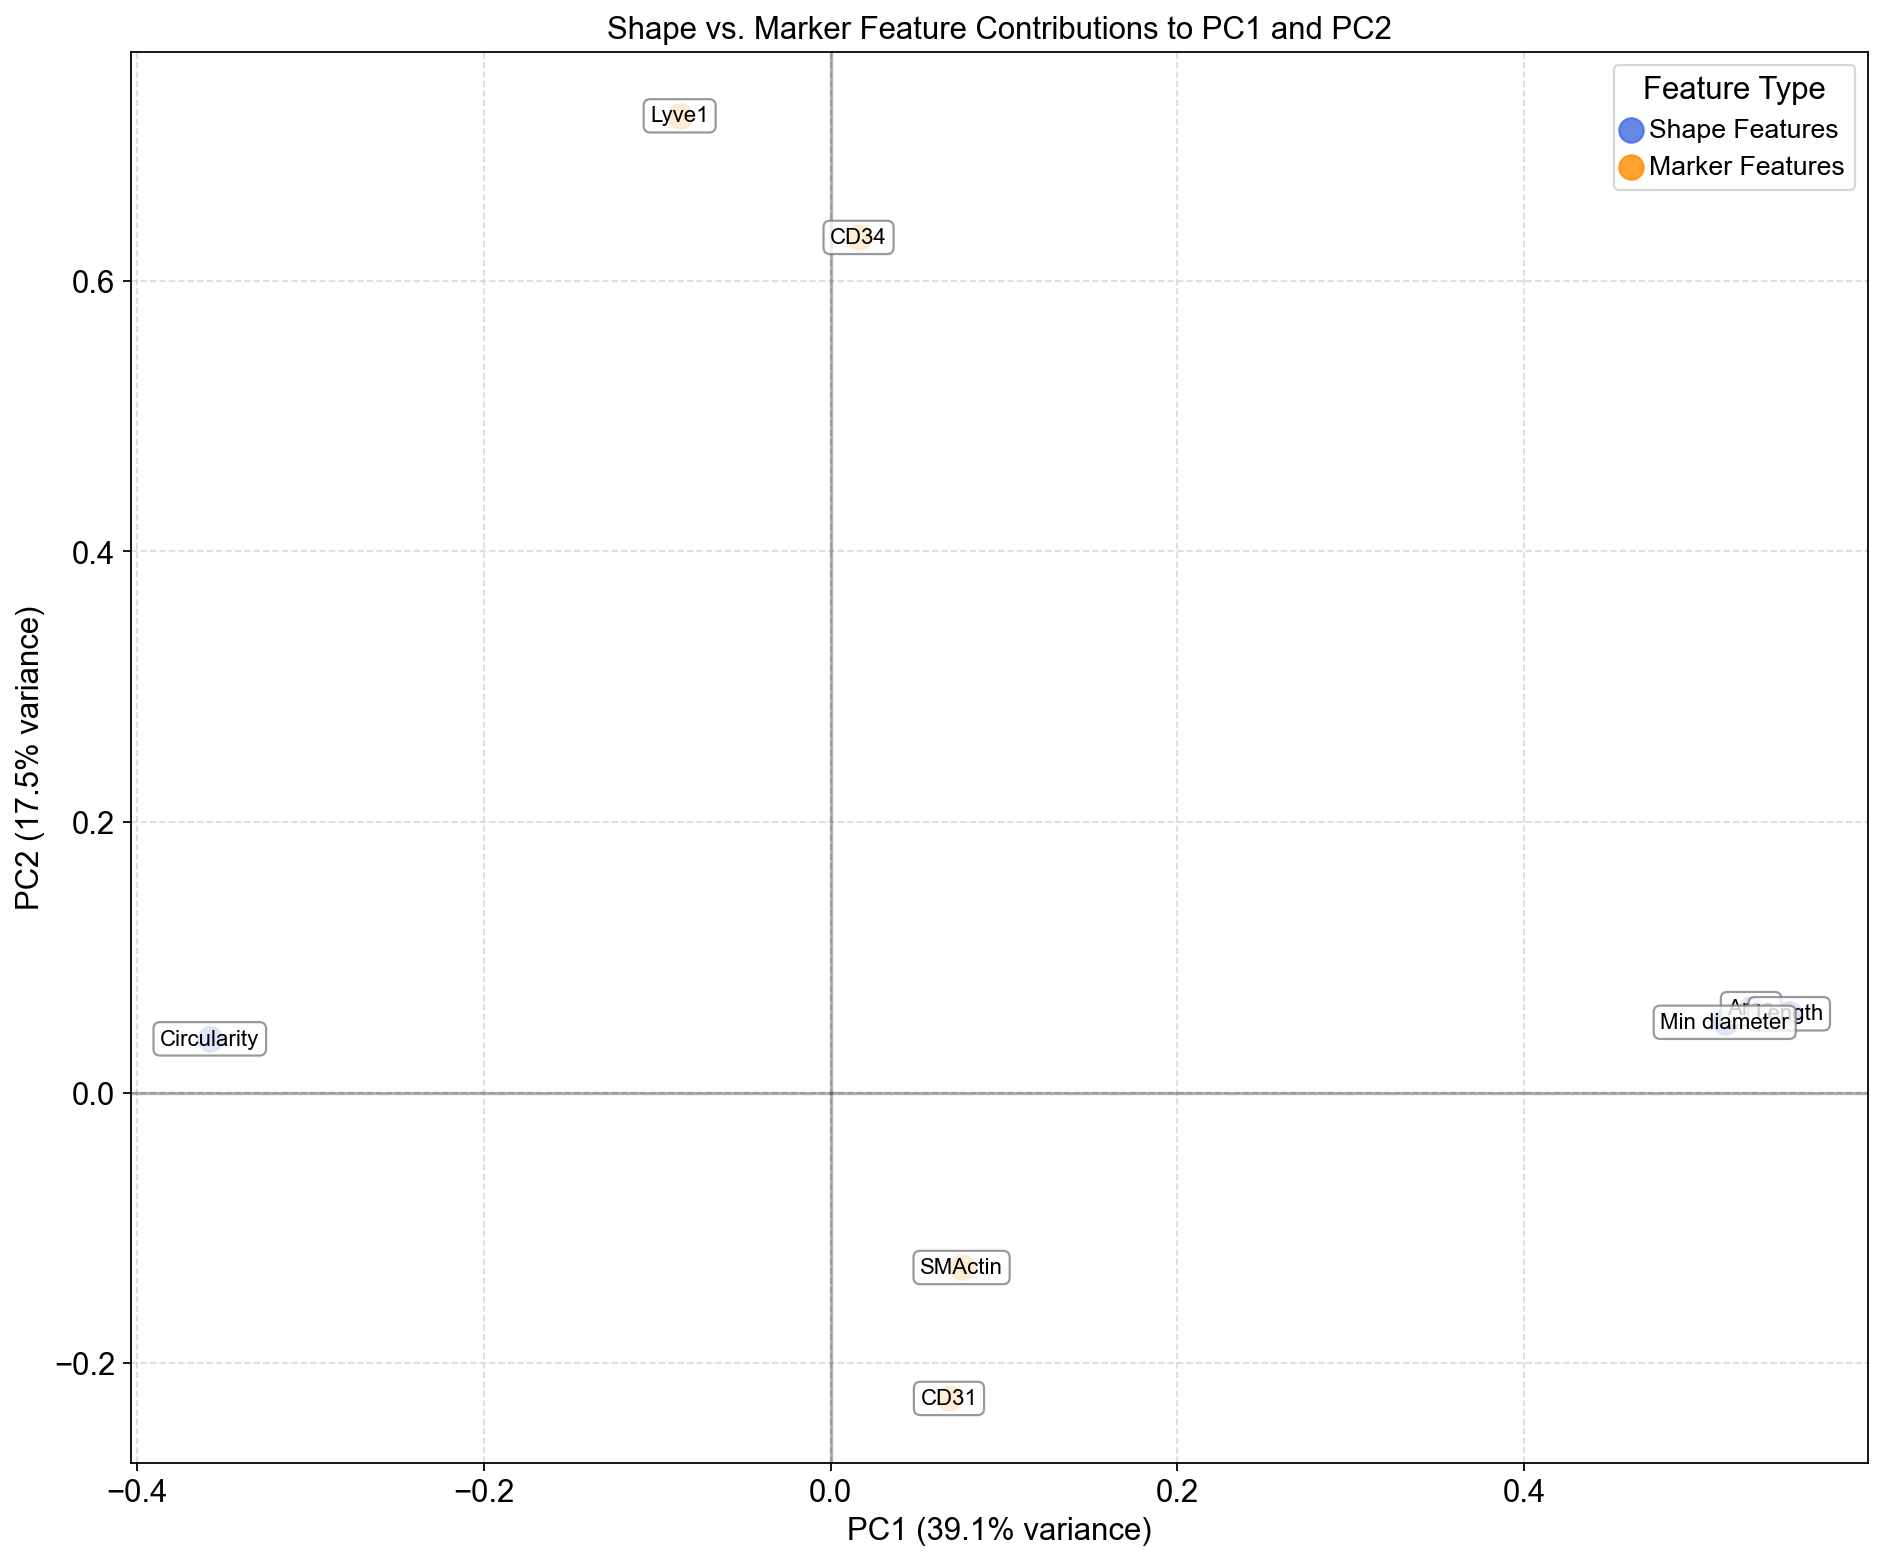

In [ ]:
# Visualize the loadings for the first two PCs with feature types highlighted
plt.figure(figsize=(12, 10))
colors = {'Shape': 'royalblue', 'Marker': 'darkorange'}

for feature_type in ['Shape', 'Marker']:
    subset = loadings[loadings['Type'] == feature_type]
    plt.scatter(subset['PC1'], subset['PC2'], s=120, 
               label=f'{feature_type} Features', 
               alpha=0.8, color=colors[feature_type])

plt.grid(True, linestyle='--', alpha=0.7)

# Add variable names as annotations
for i, row in loadings.iterrows():
    plt.annotate(i, (row['PC1'], row['PC2']), 
                fontsize=10, ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Add reference lines
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.xlabel(f'PC1 ({combined_adata.uns["pca"]["variance_ratio"][0]:.1%} variance)')
plt.ylabel(f'PC2 ({combined_adata.uns["pca"]["variance_ratio"][1]:.1%} variance)')
plt.title('Shape vs. Marker Feature Contributions to PC1 and PC2')
plt.legend(title='Feature Type', fontsize=12)
plt.tight_layout()
plt.show()

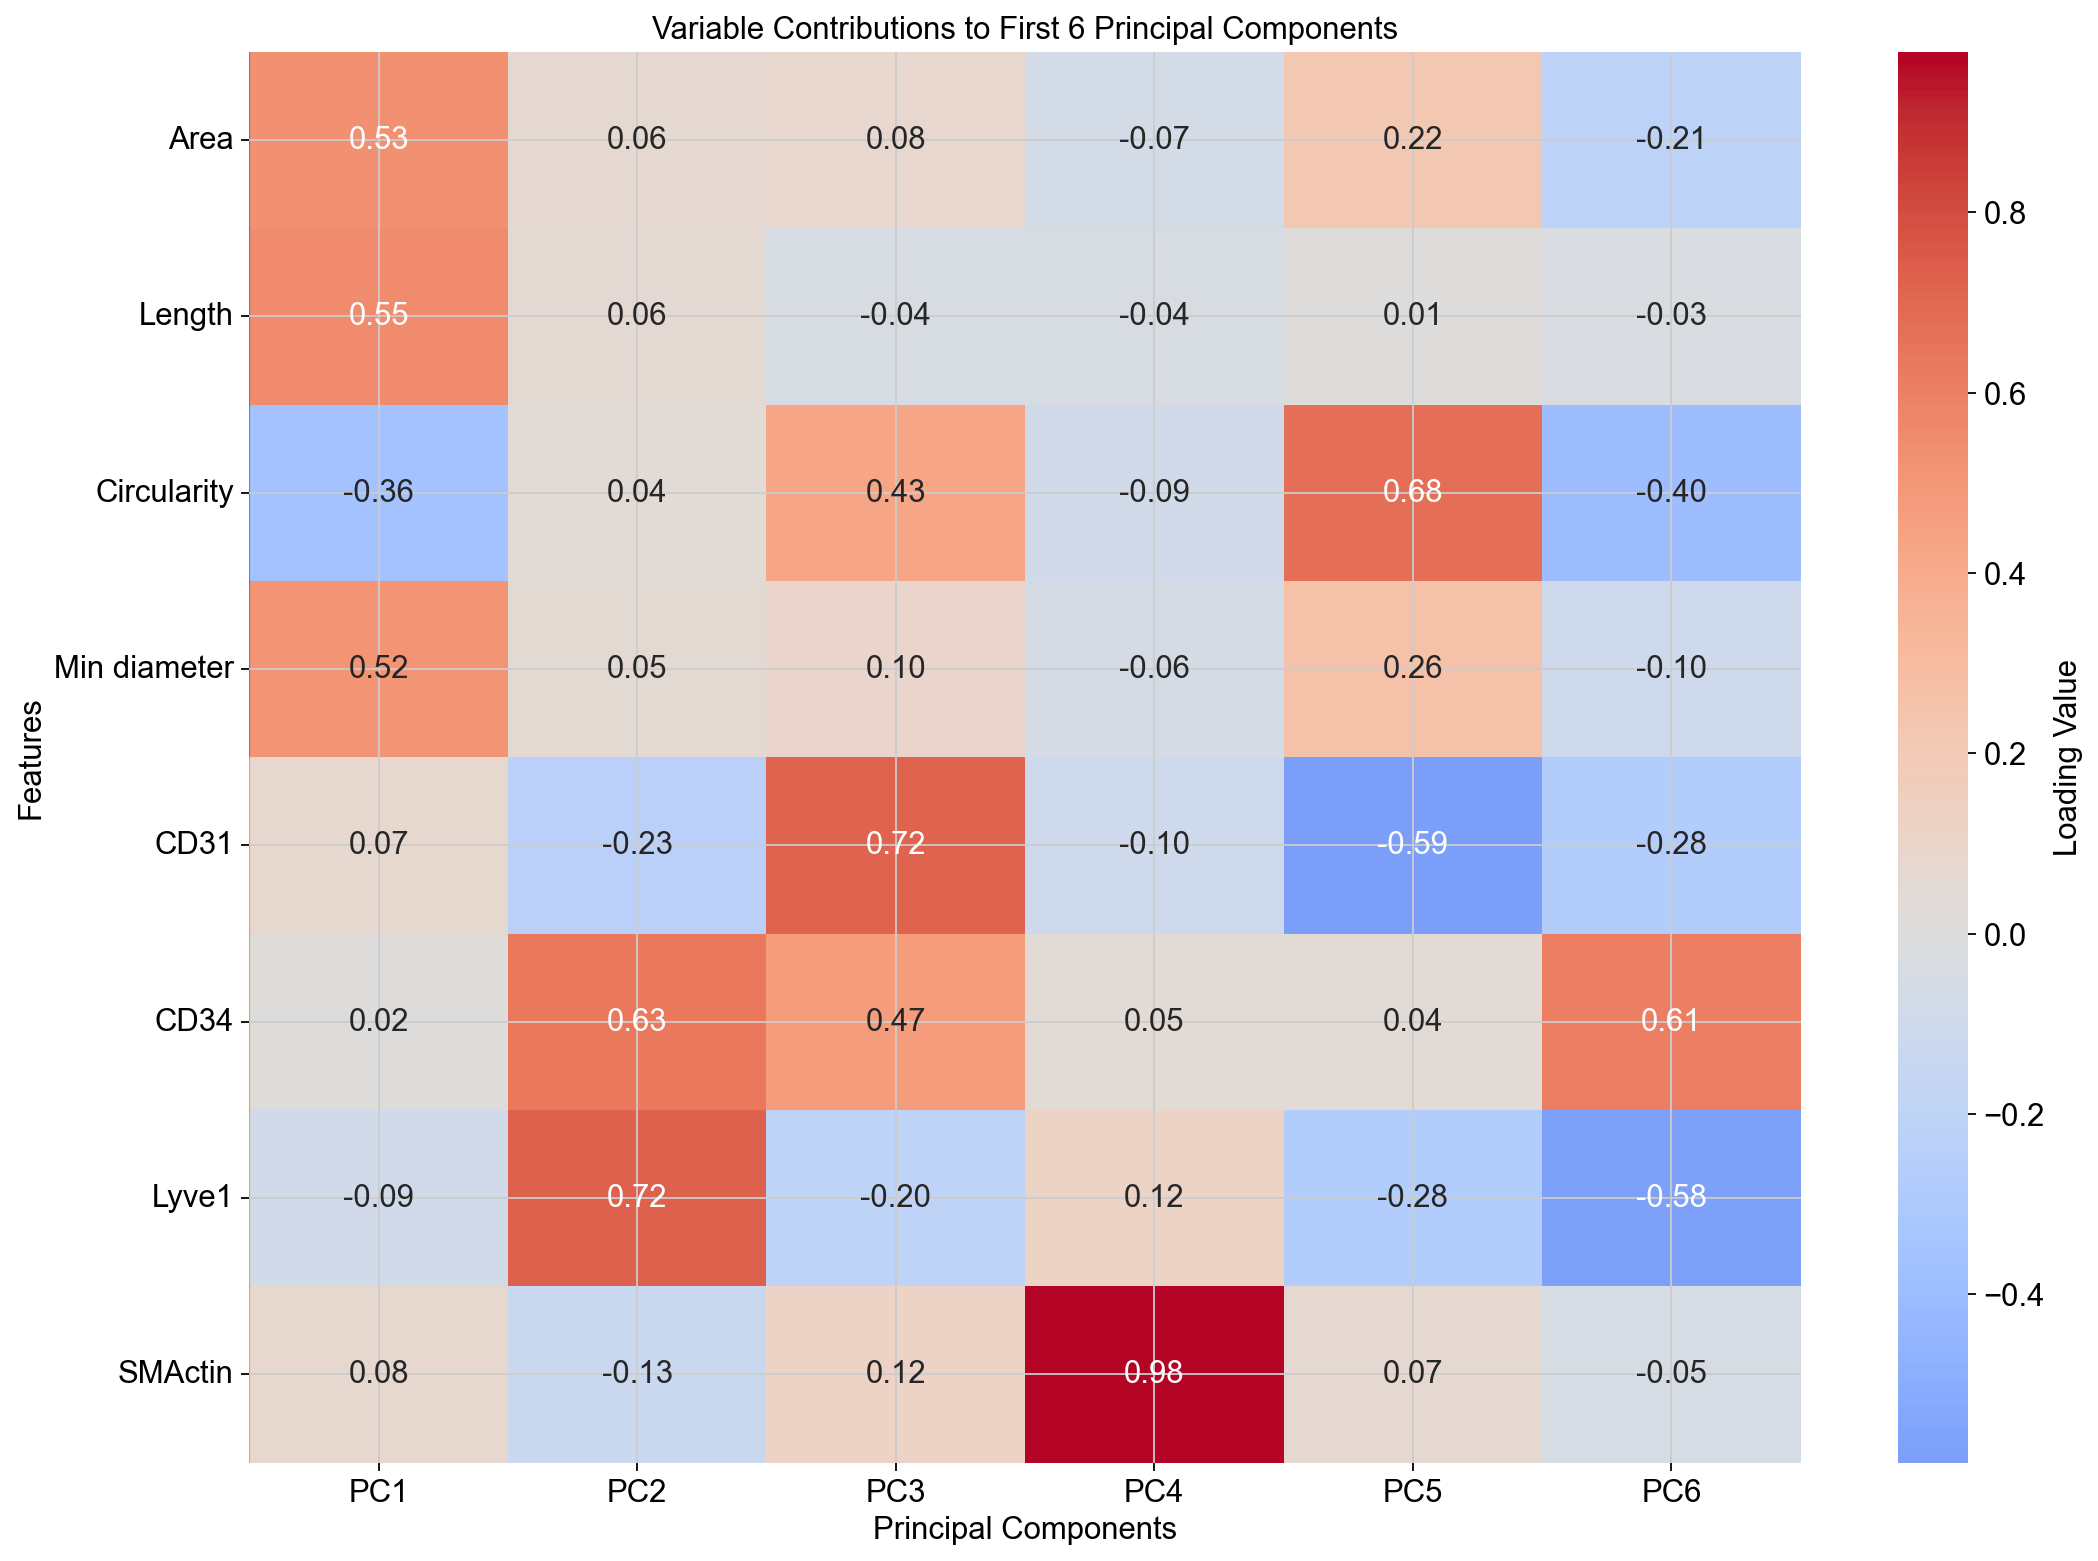

In [ ]:
# Heatmap of loadings for first 6 PCs
plt.figure(figsize=(14, 10))
loadings_for_heatmap = loadings.iloc[:, :6]  # First 6 PCs
row_colors = [colors[t] for t in loadings['Type']]

# Create the heatmap
sns.heatmap(loadings_for_heatmap, annot=True, cmap='coolwarm', center=0, fmt=".2f", 
            cbar_kws={'label': 'Loading Value'})
plt.title('Variable Contributions to First 6 Principal Components')
plt.ylabel('Features')
plt.xlabel('Principal Components')

# Add colored bars for feature types
for i, (idx, row) in enumerate(loadings.iterrows()):
    plt.gca().add_patch(plt.Rectangle((-0.5, i), 0.5, 1, 
                                     color=colors[row['Type']], alpha=0.7))

plt.tight_layout()
plt.show()

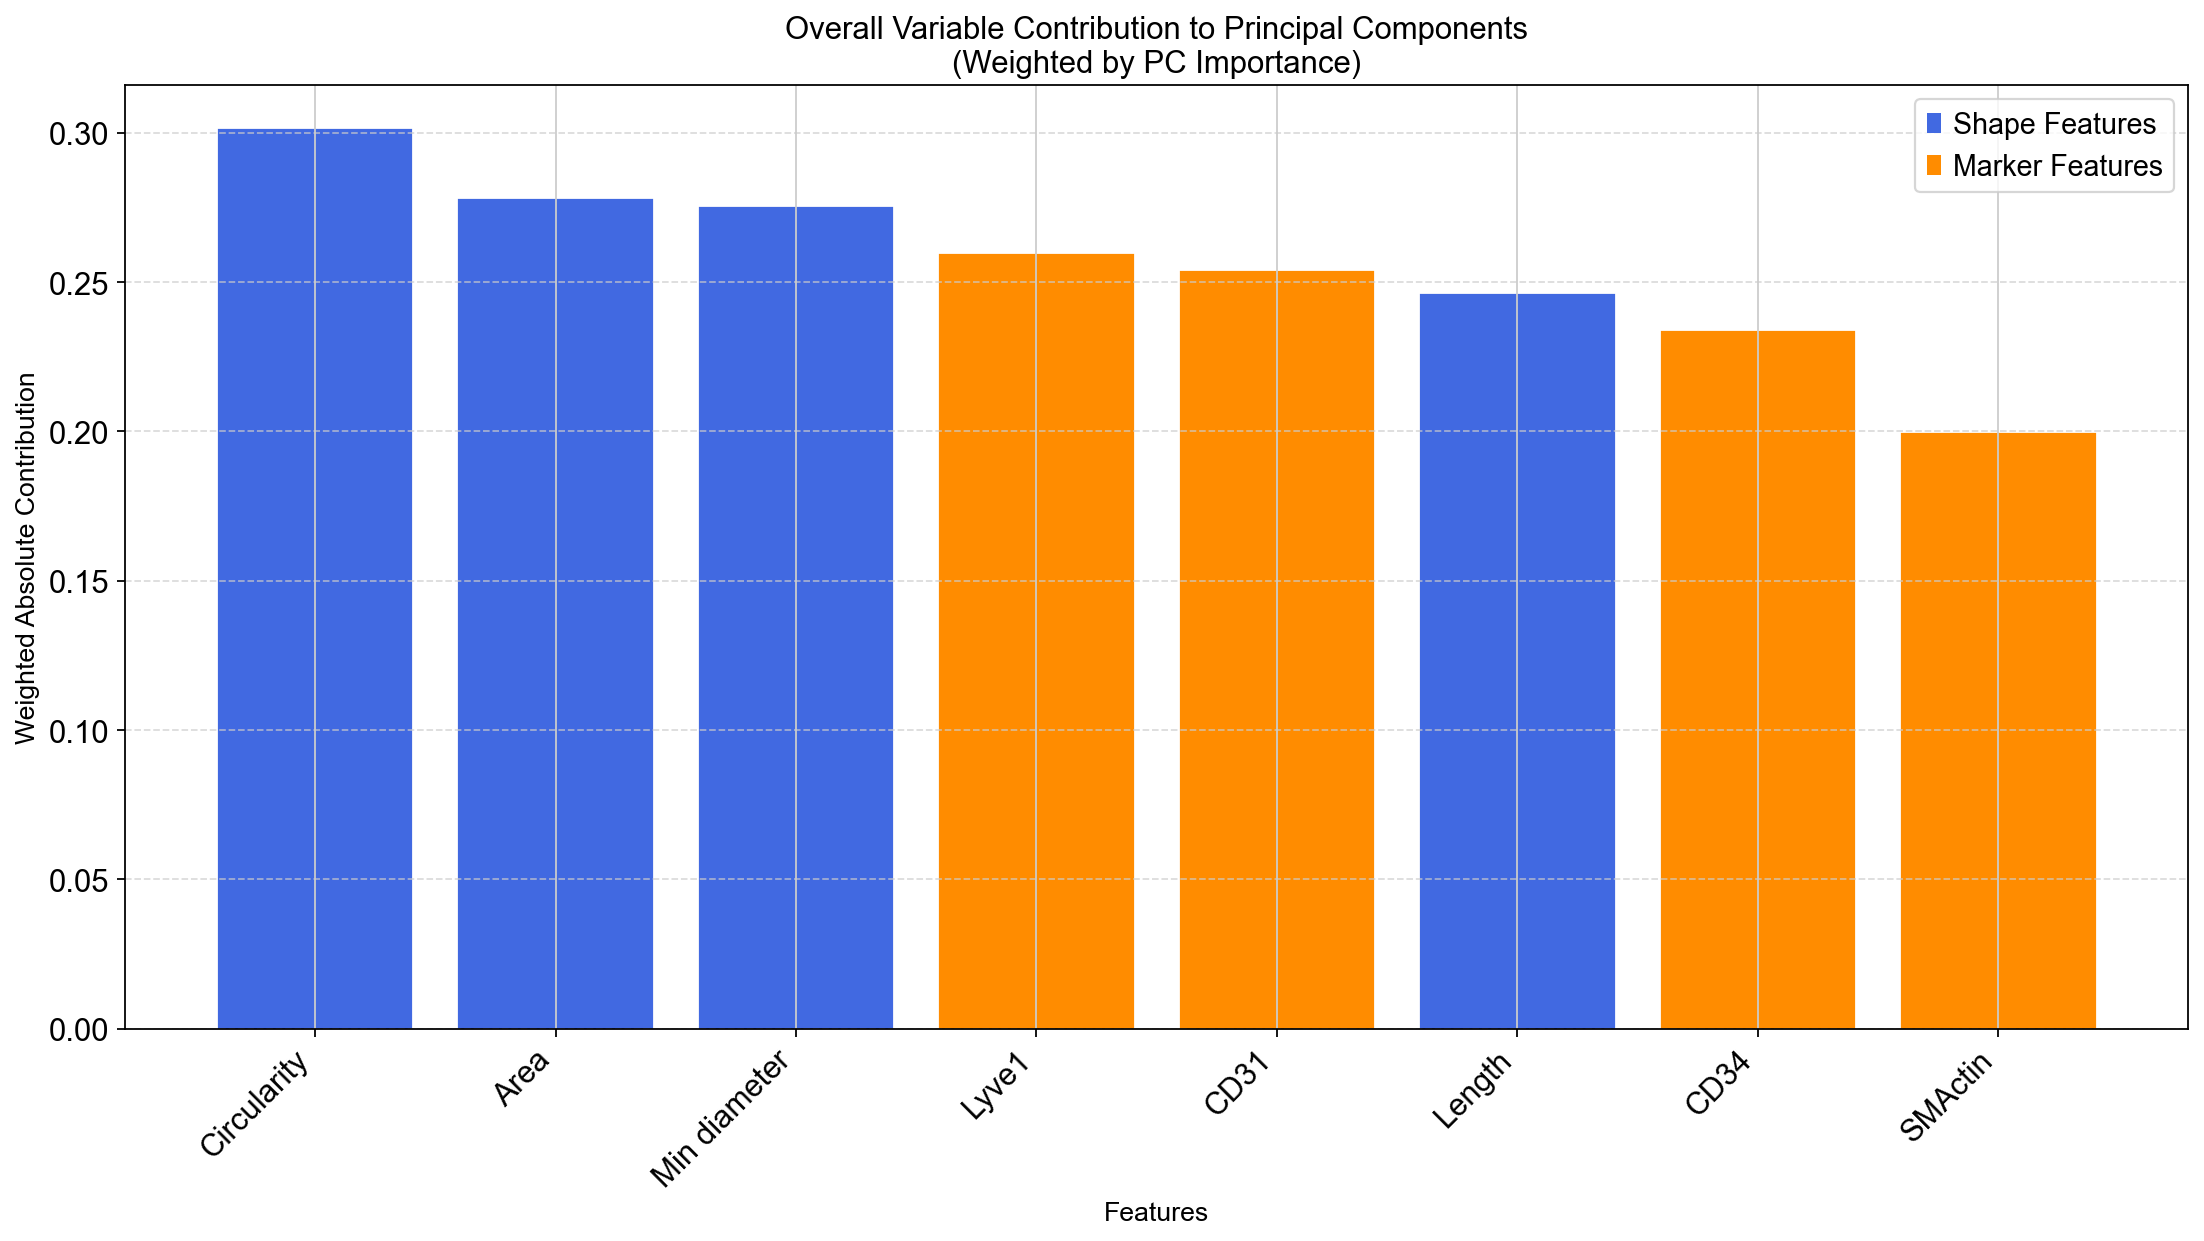

In [ ]:
# Calculate weighted contributions
explained_variance_ratio = combined_adata.uns['pca']['variance_ratio']
weighted_loadings = loadings.copy()
for i in range(loadings.shape[1]-1):  # -1 to exclude Type column
    weighted_loadings.iloc[:, i] = np.abs(loadings.iloc[:, i]) * explained_variance_ratio[i]

# Sum up the absolute contributions across all PCs
total_contribution = weighted_loadings.iloc[:, :-1].sum(axis=1)  # Exclude Type column
total_contribution = total_contribution.sort_values(ascending=False)

# Plot the total contribution of each variable
plt.figure(figsize=(14, 8))
bars = plt.bar(range(len(total_contribution)), total_contribution.values)

# Color the bars by feature type
for i, (feature, value) in enumerate(total_contribution.items()):
    feature_type = 'Shape' if feature in shape_feature_names else 'Marker'
    bars[i].set_color(colors[feature_type])

plt.title('Overall Variable Contribution to Principal Components\n(Weighted by PC Importance)', fontsize=14)
plt.ylabel('Weighted Absolute Contribution', fontsize=12)
plt.xlabel('Features', fontsize=12)
plt.xticks(range(len(total_contribution)), total_contribution.index, rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors['Shape'], label='Shape Features'),
    Patch(facecolor=colors['Marker'], label='Marker Features')
]
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
print("\nTop 10 Contributing Features:")
for i, (feature, value) in enumerate(total_contribution.head(10).items()):
    feature_type = 'Shape' if feature in shape_feature_names else 'Marker'
    print(f"{i+1:2d}. {feature:15s} ({feature_type:6s}): {value:.4f}")

# Show feature type distribution in top contributors
top_10_types = [('Shape' if f in shape_feature_names else 'Marker') for f in total_contribution.head(10).index]
print(f"\nTop 10 feature types: Shape={top_10_types.count('Shape')}, Marker={top_10_types.count('Marker')}")

# Store the combined analysis results
vdata.uns['pca_combined'] = {
    'loadings': loadings,
    'total_contribution': total_contribution,
    'explained_variance_ratio': explained_variance_ratio
}


Top 10 Contributing Features:
 1. Circularity     (Shape ): 0.2641
 2. Solidity        (Shape ): 0.2593
 3. Area            (Shape ): 0.2592
 4. Min diameter    (Shape ): 0.2484
 5. Max diameter    (Shape ): 0.2434
 6. Length          (Shape ): 0.2333
 7. Perimeter       (Shape ): 0.2333
 8. CD31            (Marker): 0.1960
 9. CD34            (Marker): 0.1957
10. Lyve1           (Marker): 0.1767

Top 10 feature types: Shape=7, Marker=3
